# Customer Churn Prediction — Telco Dataset
### End-to-end Data Science Assignment

---

## Business Problem

A telecommunications company loses a meaningful share of its subscriber base every month.
Acquiring a new customer costs several times more than retaining an existing one, so the
**retention team wants a ranked list of customers who are about to leave**, early enough to
act (call them, offer a discount, upgrade their plan, fix a service issue).

Our job as Data Scientists is to turn the historical customer table into a **deployable
prediction service**:

> Given everything we know about a customer today, what is the probability that they will churn — and is that probability high enough to put them on the retention team's call list?

**Target variable:** `Churn` (Yes / No)
**Dataset:** IBM Telco Customer Churn — 7,043 customers × 21 columns

---

## Solution Roadmap

| # | Stage | What happens |
|---|-------|--------------|
| 1 | Data Understanding & Preparation | Structure, dtypes, missing values, duplicates, target analysis, cleaning, encoding strategy, 70:30 split |
| 2 | Exploratory Data Analysis | 8+ visualisations, each with a business insight |
| 3 | Feature Engineering | 8 new leakage-free features with justification |
| 4 | Model Development | 4 Decision Tree configurations + GridSearchCV, compared |
| 5 | Model Evaluation | Accuracy / Precision / Recall / F1 / Confusion Matrix / ROC / PR, business interpretation |
| 6 | Model Interpretation | Feature importance, tree visualisation, extracted business rules |
| 7 | Model Saving & API | `joblib` bundle + FastAPI `POST /predict` |
| 8 | Bonus | Hyper-parameter tuning, class-imbalance handling, threshold & cost optimisation, 3 extra models |

---

## Two rules that govern every decision in this notebook

**Rule 1 — No data leakage.** Nothing that is learned from the data (imputation medians,
one-hot categories, scaling statistics) may be computed before the train/test split. Every
such step lives *inside* a `scikit-learn` `Pipeline`, which is fitted on the training fold only.

**Rule 2 — Whatever we do in training must be reproducible at serving time.** All cleaning and
feature engineering is written once in `churn_features.py` and imported by the notebook *and*
the API, so a live request goes through byte-for-byte the same transformations as a training row.

---
# 0. Environment Setup

We import the libraries once, fix the random seed, and configure plotting defaults so every
chart in the notebook has a consistent look.

`RANDOM_STATE = 42` is used in **every** place that involves randomness (the split, the trees,
the cross-validation folds) — that is what makes the whole notebook reproducible: re-running it
gives identical numbers.

In [102]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

# ---- Reproducibility --------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.30
np.random.seed(RANDOM_STATE)

# ---- Project paths ----------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "TelcoCustomerChurn.csv"
MODEL_DIR = PROJECT_ROOT / "model"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR.mkdir(exist_ok=True, parents=True)
sys.path.insert(0, str(PROJECT_ROOT))     # so that `import churn_features` works

# ---- Plot styling -----------------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})
CHURN_PALETTE = {"No": "#2E86AB", "Yes": "#E4572E"}

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

def save_fig(name):
    '''Persist the current figure into reports/figures for the README / slides.'''
    plt.savefig(FIG_DIR / f"{name}.png")

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("Project root:", PROJECT_ROOT)

Python      : 3.14.4
pandas      : 3.0.5
numpy       : 2.5.3
scikit-learn: 1.9.1
Project root: d:\NAGP\DS Project\customer_churn_project


---
# 1. Data Understanding & Preparation

## 1.1 Load the data and take a first look

In [103]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 7,043   Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [104]:
# The supplied data dictionary tells us what each column is supposed to mean.
data_dict = pd.read_csv(PROJECT_ROOT / "data" / "TelcoCustomerChurn_DataDictionary.csv")
data_dict

,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


### Observation — the columns fall into four natural business groups

| Group | Columns | Business meaning |
|---|---|---|
| **Identity** | `customerID` | Unique key — no predictive value, must be dropped |
| **Demographics** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Who the customer is |
| **Services** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | What they bought |
| **Account** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` | How they pay and how long they have stayed |

Thinking in these groups matters later: retention levers are almost always in the
**Account** and **Services** groups (you can change a contract or add tech support; you
cannot change a customer's age).

## 1.2 Data types and structure check

In [105]:
print(df_raw.info())
print("\nMemory usage: %.2f MB" % (df_raw.memory_usage(deep=True).sum() / 1024**2))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [106]:
# Explicit dtype audit: what pandas inferred vs. what the column really is.
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
    "sample_values": [df_raw[c].dropna().unique()[:4].tolist() for c in df_raw.columns],
})
audit

,dtype,n_unique,n_missing,sample_values
customerID,str,7043,0,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,str,2,0,"[Female, Male]"
SeniorCitizen,int64,2,0,"[0, 1]"
Partner,str,2,0,"[Yes, No]"
Dependents,str,2,0,"[No, Yes]"
tenure,int64,73,0,"[1, 34, 2, 45]"
PhoneService,str,2,0,"[No, Yes]"
MultipleLines,str,3,0,"[No phone service, No, Yes]"
InternetService,str,3,0,"[DSL, Fiber optic, No]"
OnlineSecurity,str,3,0,"[No, Yes, No internet service]"


Observation 1 — `TotalCharges` is stored as text, not as a number

`TotalCharges` is clearly a monetary amount, yet pandas parsed it as `object`/`str`. That
always means at least one value is not numeric. If we ignored this, the column would be
silently one-hot encoded into ~6,500 useless dummy columns, or would crash the model.

Observation 2 — `SeniorCitizen` is an `int64` but is really a Yes/No flag

It is already 0/1, so it is harmless, but treating it as *numeric* would let a tree compute
meaningless splits like "SeniorCitizen <= 0.5". We convert it to a proper categorical label so
it is one-hot encoded consistently with `Partner`, `Dependents`, etc.

Observation 3 — the "No internet service" / "No phone service" pattern

Six service columns use a third level, `No internet service`, which is *not* a missing value —
it is a legitimate state that is perfectly collinear with `InternetService == "No"`. We keep it
as its own category: it carries the information "this customer has no internet at all", which
the EDA will show is the single lowest-churn segment.

## 1.3 Missing-value analysis

Two layers of missingness must be checked:
1. **Explicit** nulls (`NaN`) — what `isnull()` finds.
2. **Implicit / disguised** nulls — blanks, `" "`, `"?"`, `"unknown"`, `-1` — what `isnull()` *misses*.

The Telco dataset is a textbook case of the second kind.

In [107]:
print("=== Layer 1: explicit nulls ===")
print(df_raw.isnull().sum().to_string())
print(f"\nTotal explicit nulls: {df_raw.isnull().sum().sum()}")

=== Layer 1: explicit nulls ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

Total explicit nulls: 0


In [108]:
print("=== Layer 2: disguised nulls (blank / whitespace-only strings) ===")
blank_counts = {}
for col in df_raw.columns:
    if df_raw[col].dtype == object or str(df_raw[col].dtype) in ("str", "string"):
        blank_counts[col] = (df_raw[col].astype(str).str.strip() == "").sum()
blank = pd.Series(blank_counts)
print(blank[blank > 0].to_string() if (blank > 0).any() else "none")

# Coerce TotalCharges and see how many values fail to parse
tc_numeric = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
print(f"\nTotalCharges values that cannot be parsed as a number: {tc_numeric.isna().sum()}")

=== Layer 2: disguised nulls (blank / whitespace-only strings) ===
TotalCharges    11

TotalCharges values that cannot be parsed as a number: 11


In [109]:
# WHO are these 11 customers? Never impute before you understand the mechanism.
problem_rows = df_raw.loc[tc_numeric.isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "PaperlessBilling", "Churn"]]
print(problem_rows.to_string(index=False))
print("\ntenure values of these rows:", sorted(problem_rows["tenure"].unique()))
print("Churn values of these rows :", problem_rows["Churn"].unique().tolist())

customerID  tenure  MonthlyCharges TotalCharges Contract PaperlessBilling Churn
4472-LVYGI       0           52.55              Two year              Yes    No
3115-CZMZD       0           20.25              Two year               No    No
5709-LVOEQ       0           80.85              Two year               No    No
4367-NUYAO       0           25.75              Two year               No    No
1371-DWPAZ       0           56.05              Two year               No    No
7644-OMVMY       0           19.85              Two year               No    No
3213-VVOLG       0           25.35              Two year               No    No
2520-SGTTA       0           20.00              Two year               No    No
2923-ARZLG       0           19.70              One year              Yes    No
4075-WKNIU       0           73.35              Two year               No    No
2775-SEFEE       0           61.90              Two year              Yes    No

tenure values of these rows: [np.int64(

## 1.4 Duplicate analysis

In [110]:
print("Exact duplicate rows                   :", df_raw.duplicated().sum())
print("Duplicate customerIDs                  :", df_raw["customerID"].duplicated().sum())
print("Unique customerIDs                     :", df_raw["customerID"].nunique(), "of", len(df_raw))

# Duplicates ignoring the ID: two different IDs with identical attributes are plausible
# (two similar customers), not necessarily an error - we only report them.
dupe_feats = df_raw.drop(columns=["customerID"]).duplicated().sum()
print("Rows identical on all non-ID columns   :", dupe_feats)

Exact duplicate rows                   : 0
Duplicate customerIDs                  : 0
Unique customerIDs                     : 7043 of 7043
Rows identical on all non-ID columns   : 22


## 1.5 Numerical and categorical feature identification


In [111]:
df = df_raw.copy()
df["TotalCharges"] = tc_numeric   # provisional numeric version for profiling only

TRUE_NUMERIC = ["tenure", "MonthlyCharges", "TotalCharges"]
TRUE_CATEGORICAL = [c for c in df.columns
                    if c not in TRUE_NUMERIC + ["customerID", "Churn"]]

print(f"Numerical features   ({len(TRUE_NUMERIC)}): {TRUE_NUMERIC}")
print(f"Categorical features ({len(TRUE_CATEGORICAL)}): {TRUE_CATEGORICAL}")
print(f"Identifier           : customerID  (dropped)")
print(f"Target               : Churn")

print("\n--- Cardinality of every categorical feature ---")
for c in TRUE_CATEGORICAL:
    print(f"{c:<20} {df[c].nunique()} levels -> {sorted(map(str, df[c].unique()))}")

Numerical features   (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Identifier           : customerID  (dropped)
Target               : Churn

--- Cardinality of every categorical feature ---
gender               2 levels -> ['Female', 'Male']
SeniorCitizen        2 levels -> ['0', '1']
Partner              2 levels -> ['No', 'Yes']
Dependents           2 levels -> ['No', 'Yes']
PhoneService         2 levels -> ['No', 'Yes']
MultipleLines        3 levels -> ['No', 'No phone service', 'Yes']
InternetService      3 levels -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity       3 levels -> ['No', 'No internet service', 'Yes']
OnlineBackup         3 levels -> ['No', 'No internet service', 'Yes']
DeviceProtectio

In [112]:
df[TRUE_NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


### 🔍 Observations on the numerical features

* **`tenure`** spans 0–72 months (6 years) with a mean of 32. The distribution is *bimodal*
  (we will see this in the EDA): a big cluster of brand-new customers and a big cluster of
  6-year loyalists. That shape alone tells us tenure will be a powerful predictor.
* **`MonthlyCharges`** spans ₹18.25–₹118.75. Also bimodal — a cheap phone-only tier around ₹20
  and an expensive fiber+streaming tier around ₹80–100.
* **`TotalCharges`** is heavily right-skewed (mean 2,283 vs median 1,397) and is essentially
  `tenure × MonthlyCharges` — we confirm this correlation below. It is therefore a **redundant**
  feature in the linear sense, but still useful to a tree as a "how much has this customer
  already spent with us" signal.
* **No negative values and no absurd outliers** — the ranges are all business-plausible, so
  **no outlier removal is performed**. Decision trees are split-based and are inherently robust
  to outliers anyway (a split point does not care how far away the extreme value is).


## 1.6 Target-variable analysis

In [113]:
target_counts = df["Churn"].value_counts()
target_pct = df["Churn"].value_counts(normalize=True) * 100
summary = pd.DataFrame({"count": target_counts, "percentage": target_pct.round(2)})
print(summary.to_string())

imbalance_ratio = target_counts["No"] / target_counts["Yes"]
print(f"\nImbalance ratio (No:Yes) = {imbalance_ratio:.2f} : 1")
print(f"Majority-class baseline accuracy = {target_pct['No']:.2f}%  <-- any model must beat this")

       count  percentage
Churn                   
No      5174       73.46
Yes     1869       26.54

Imbalance ratio (No:Yes) = 2.77 : 1
Majority-class baseline accuracy = 73.46%  <-- any model must beat this


### 💡 Key preprocessing decision #3 — class imbalance

26.54% churn is **moderately imbalanced**. The danger is concrete and worth stating precisely:

> A model that predicts "No Churn" for **every single customer** achieves **73.46% accuracy**
> and is completely worthless to the business — it would find zero churners.

This is why **accuracy alone is a misleading metric here** and why we will judge models on
Recall / F1 / ROC-AUC instead, and why the final tree uses `class_weight="balanced"`, which
re-weights each class by `n_samples / (n_classes × n_class_samples)` — roughly 1.89× weight on
churners and 0.68× on non-churners. The tree then treats one missed churner as ≈2.8 times
worse than one false alarm, which matches the business reality.

## 1.7 Data cleaning — implementation

All cleaning logic lives in **`churn_features.py`** at the project root, in one function:
`clean_raw_dataframe()`. Keeping it in an importable module (rather than in notebook cells) is
what allows the *identical* code to run inside the saved pipeline and inside the API.

What it does:

| Step | Rationale |
|---|---|
| Drop `customerID` | Unique key; a tree could memorise individual customers → pure overfitting |
| Strip whitespace from all text columns | `"Yes "` and `"Yes"` must not become two categories |
| `TotalCharges` → numeric, blanks → `tenure × MonthlyCharges` | Decision #1 above |
| `SeniorCitizen` 0/1 → `"No"/"Yes"` | Makes it a true categorical; also lets the API accept either form |

It is deliberately **idempotent and row-wise**, so it behaves identically on 7,043 rows or on
one JSON payload.

In [114]:
import churn_features as cf
import importlib; importlib.reload(cf)

df_clean = cf.clean_raw_dataframe(df_raw)
print("Shape after cleaning:", df_clean.shape, " (customerID dropped)")
print("\nDtypes after cleaning:")
print(df_clean.dtypes.astype(str).to_string())
print("\nRemaining NaNs:", df_clean.isna().sum().sum())
print("\nThe 11 repaired rows (tenure = 0):")
print(df_clean.loc[tc_numeric.isna(), ["tenure", "MonthlyCharges", "TotalCharges", "Contract"]].head(11).to_string())

Shape after cleaning: (7043, 20)  (customerID dropped)

Dtypes after cleaning:
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object

Remaining NaNs: 0

The 11 repaired rows (tenure = 0):
      tenure  MonthlyCharges  TotalCharges  Contract
488        0           52.55           0.0  Two year
753        0           20.25           0.0  Two year
936        0           80.85           0.0  Two year
1082       0           25.75           0.0  Two year
1340       0           56.05           0.

In [115]:
# Sanity check that the repair rule is consistent with the rest of the column:
check = df_clean.assign(expected=df_clean["tenure"] * df_clean["MonthlyCharges"])
corr = check[["TotalCharges", "expected"]].corr().iloc[0, 1]
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {corr:.4f}")
print("-> the accounting identity we used for imputation holds across the whole dataset.")

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996
-> the accounting identity we used for imputation holds across the whole dataset.


## 1.8 Encoding strategy for categorical variables

In [116]:
X = df_raw.drop(columns=["Churn"])        # raw frame - the pipeline cleans it internally
y = (df_raw["Churn"] == "Yes").astype(int)  # Yes -> 1 (positive class), No -> 0

print("X shape:", X.shape)
print("y distribution:", y.value_counts().to_dict(), " | churn rate = %.2f%%" % (y.mean() * 100))
print("\nNOTE: X is the RAW frame. Cleaning + feature engineering happen INSIDE the pipeline,")
print("      which is what guarantees the API repeats them identically on new data.")

X shape: (7043, 20)
y distribution: {0: 5174, 1: 1869}  | churn rate = 26.54%

NOTE: X is the RAW frame. Cleaning + feature engineering happen INSIDE the pipeline,
      which is what guarantees the API repeats them identically on new data.


## 1.9 Train / Test split — 70:30, `random_state=42`, **stratified**


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X):.1%})  churn = {y_train.mean():.2%}")
print(f"Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X):.1%})  churn = {y_test.mean():.2%}")
print(f"\nChurners in train: {y_train.sum():,}   Churners in test: {y_test.sum():,}")
print("\nStratification check - churn rates differ by %.3f pp -> perfectly balanced split."
      % abs(y_train.mean() - y_test.mean()) )

Training set : 4,930 rows (70.0%)  churn = 26.53%
Test set     : 2,113 rows (30.0%)  churn = 26.55%

Churners in train: 1,308   Churners in test: 561

Stratification check - churn rates differ by 0.000 pp -> perfectly balanced split.


---
# 2. Exploratory Data Analysis


In [118]:
# Assemble a convenient analysis frame from the TRAINING data only.
eda = cf.clean_raw_dataframe(X_train).copy()
eda["Churn"] = np.where(y_train.values == 1, "Yes", "No")
print("EDA frame (training data only):", eda.shape)
eda.head(3)

EDA frame (training data only): (4930, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5557,Female,No,No,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,80.20,384.25,No
2270,Female,Yes,No,No,3,Yes,No,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,86.85,220.95,Yes
6930,Female,No,Yes,No,3,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes


## Visualisation 1 — Churn distribution (the target)

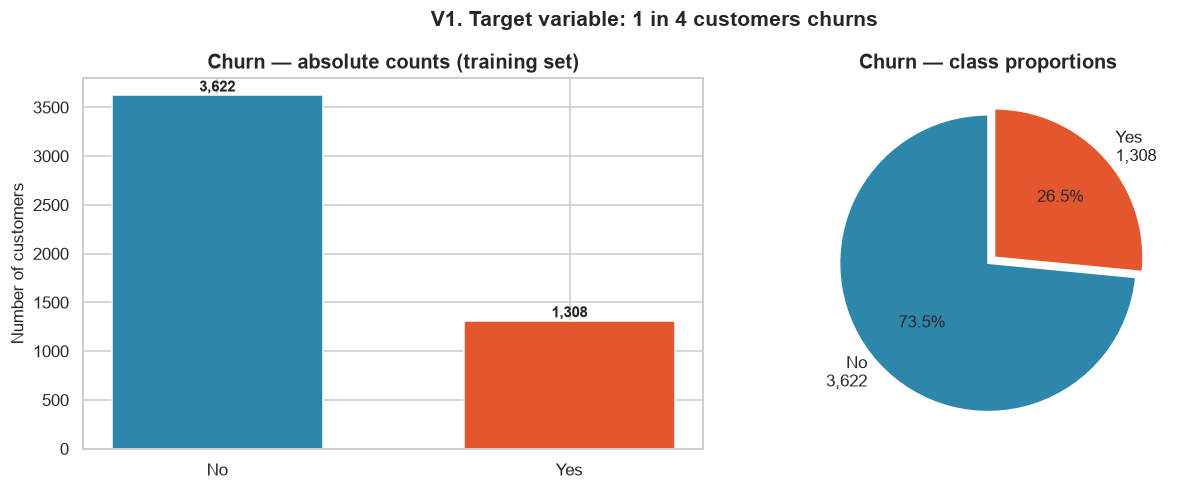

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["No", "Yes"]
counts = eda["Churn"].value_counts().reindex(order)

bars = axes[0].bar(order, counts.values, color=[CHURN_PALETTE[o] for o in order], width=.6)
axes[0].set_title("Churn — absolute counts (training set)")
axes[0].set_ylabel("Number of customers")
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 40, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=[f"{o}\n{v:,}" for o, v in zip(order, counts.values)],
            autopct="%1.1f%%", colors=[CHURN_PALETTE[o] for o in order],
            startangle=90, explode=(0, 0.06), textprops={"fontsize": 11})
axes[1].set_title("Churn — class proportions")

plt.suptitle("V1. Target variable: 1 in 4 customers churns", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v1_churn_distribution"); plt.show()

## Visualisation 2 — Distribution of the numerical variables, split by churn

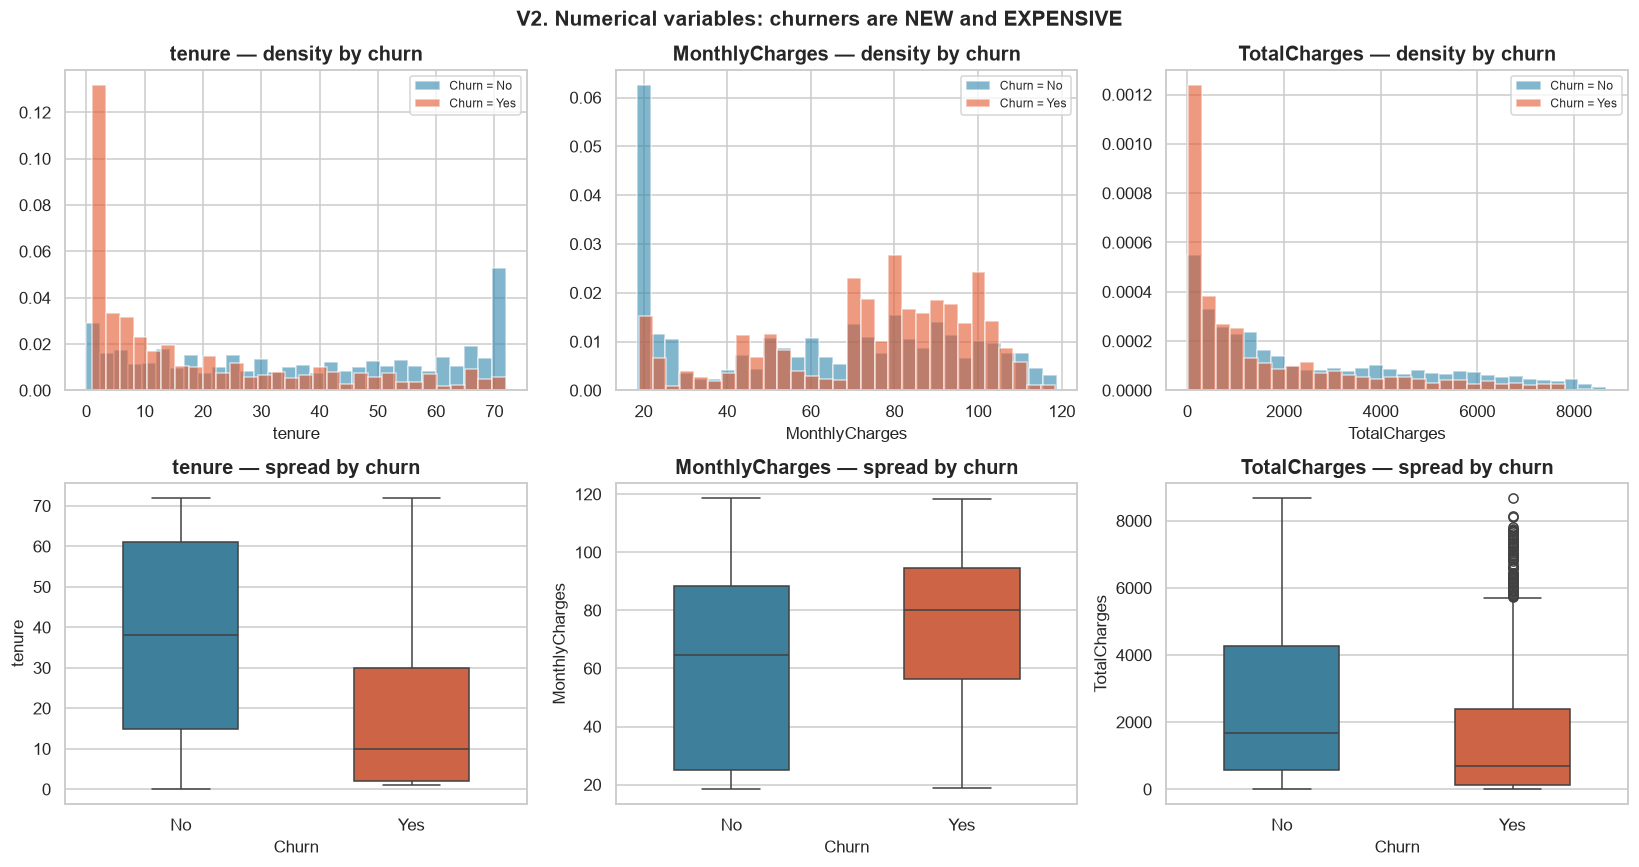

      tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.56   38.0          61.32  64.45      2563.82  1673.60
Yes    18.38   10.0          75.00  80.00      1576.22   705.08


In [120]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Row 1: overlaid histograms
    for lab in ["No", "Yes"]:
        axes[0, i].hist(eda.loc[eda["Churn"] == lab, col], bins=30, alpha=.6,
                        label=f"Churn = {lab}", color=CHURN_PALETTE[lab], density=True)
    axes[0, i].set_title(f"{col} — density by churn")
    axes[0, i].set_xlabel(col); axes[0, i].legend(fontsize=8)

    # Row 2: box plots
    sns.boxplot(data=eda, x="Churn", y=col, order=["No", "Yes"],
                palette=CHURN_PALETTE, ax=axes[1, i], width=.5)
    axes[1, i].set_title(f"{col} — spread by churn")

plt.suptitle("V2. Numerical variables: churners are NEW and EXPENSIVE", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v2_numeric_distributions"); plt.show()

print(eda.groupby("Churn")[num_cols].agg(["mean", "median"]).round(2).to_string())

## Visualisation 3 — Churn rate by contract, payment method and internet service

Instead of plotting raw counts (which just reflect segment size), we plot the **churn *rate***
per segment with the segment size annotated. That is the number a retention manager acts on.

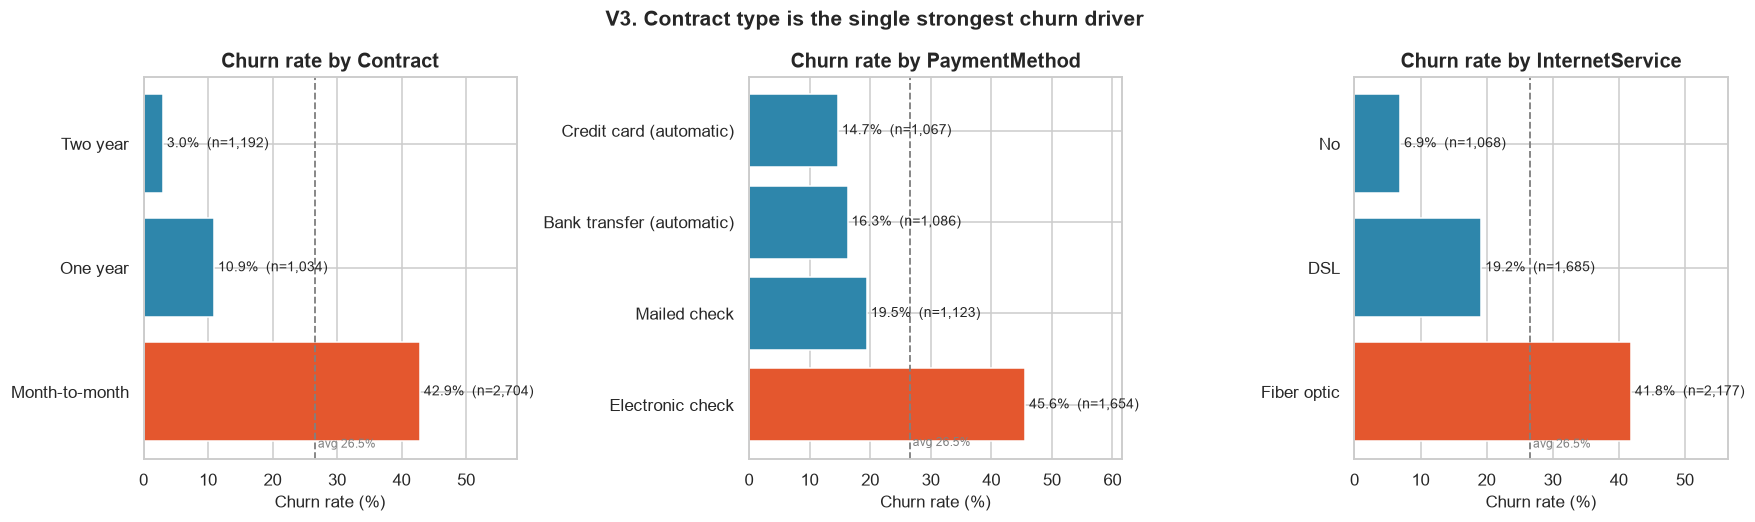

In [121]:
def churn_rate_by(frame, col):
    g = frame.groupby(col, observed=True)["Churn"].agg(
        rate=lambda s: (s == "Yes").mean() * 100, n="size").reset_index()
    return g.sort_values("rate", ascending=False)

cols3 = ["Contract", "PaymentMethod", "InternetService"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
overall = (eda["Churn"] == "Yes").mean() * 100

for ax, col in zip(axes, cols3):
    g = churn_rate_by(eda, col)
    colors = ["#E4572E" if r > overall else "#2E86AB" for r in g["rate"]]
    bars = ax.barh(g[col].astype(str), g["rate"], color=colors)
    ax.axvline(overall, ls="--", color="grey", lw=1.2)
    ax.text(overall + .5, -0.45, f"avg {overall:.1f}%", color="grey", fontsize=8)
    for b, r, n in zip(bars, g["rate"], g["n"]):
        ax.text(r + .6, b.get_y() + b.get_height()/2, f"{r:.1f}%  (n={n:,})",
                va="center", fontsize=9)
    ax.set_title(f"Churn rate by {col}"); ax.set_xlabel("Churn rate (%)")
    ax.set_xlim(0, max(g["rate"]) * 1.35)

plt.suptitle("V3. Contract type is the single strongest churn driver", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v3_churn_rate_account"); plt.show()

## Visualisation 4 — Churn across demographics and add-on services

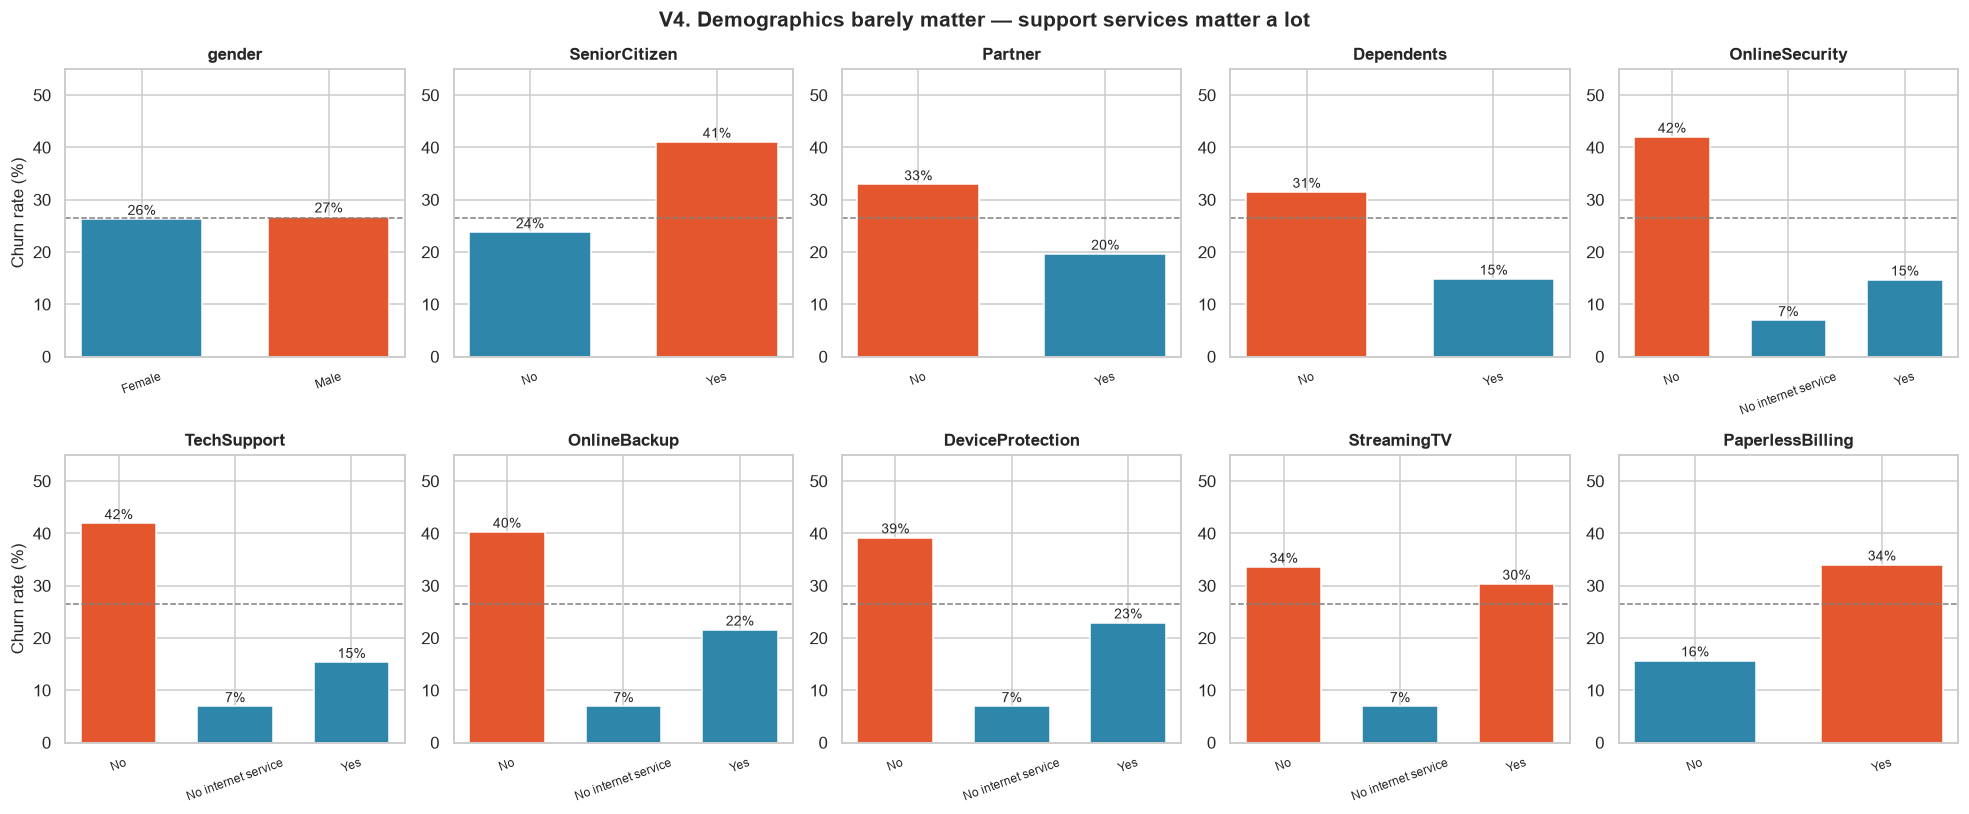

In [122]:
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]
svc_cols = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection",
            "StreamingTV", "PaperlessBilling"]
plot_cols = demo_cols + svc_cols

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for ax, col in zip(axes.ravel(), plot_cols):
    g = churn_rate_by(eda, col).sort_values(col)
    colors = ["#E4572E" if r > overall else "#2E86AB" for r in g["rate"]]
    bars = ax.bar(g[col].astype(str), g["rate"], color=colors, width=.65)
    ax.axhline(overall, ls="--", color="grey", lw=1)
    for b, r in zip(bars, g["rate"]):
        ax.text(b.get_x() + b.get_width()/2, r + .8, f"{r:.0f}%", ha="center", fontsize=9)
    ax.set_title(col, fontsize=11); ax.set_ylim(0, 55); ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)
axes[0, 0].set_ylabel("Churn rate (%)"); axes[1, 0].set_ylabel("Churn rate (%)")

plt.suptitle("V4. Demographics barely matter — support services matter a lot",
             fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v4_demographics_services"); plt.show()

## Visualisation 5 — Churn rate over the customer lifecycle (tenure curve)

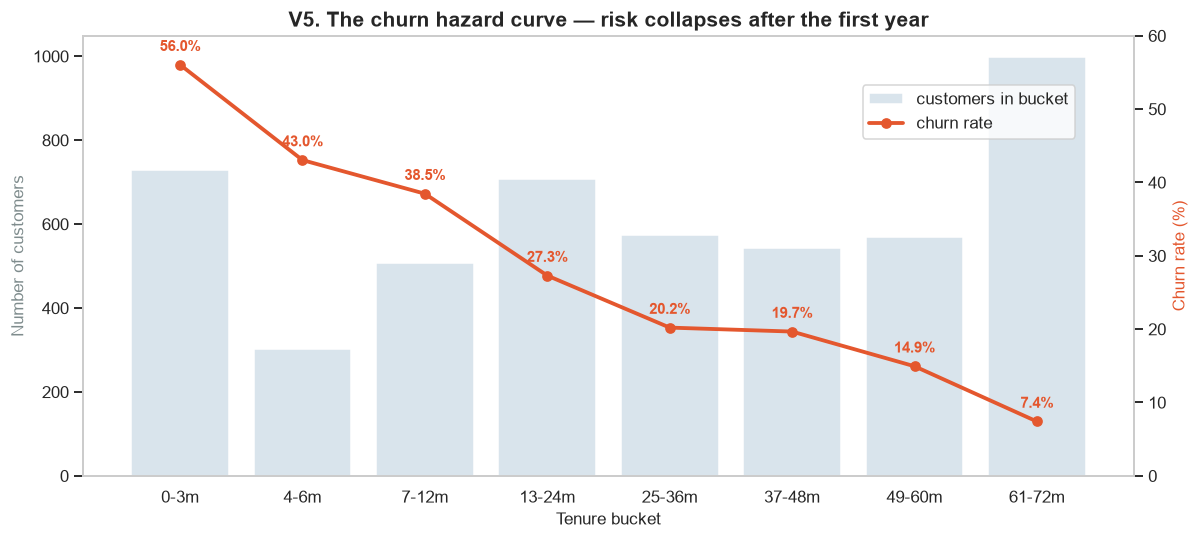

_tenure_bin      rate   n
       0-3m 56.043956 728
       4-6m 43.046358 302
      7-12m 38.461538 507
     13-24m 27.298444 707
     25-36m 20.209059 574
     37-48m 19.669118 544
     49-60m 14.938489 569
     61-72m  7.407407 999


In [123]:
eda["_tenure_bin"] = pd.cut(eda["tenure"], bins=[-.1, 3, 6, 12, 24, 36, 48, 60, 72],
                            labels=["0-3m", "4-6m", "7-12m", "13-24m", "25-36m",
                                    "37-48m", "49-60m", "61-72m"])
g = eda.groupby("_tenure_bin", observed=True)["Churn"].agg(
    rate=lambda s: (s == "Yes").mean() * 100, n="size").reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(g["_tenure_bin"].astype(str), g["n"], color="#D9E4EC", label="customers in bucket")
ax1.set_ylabel("Number of customers", color="#7f8c8d"); ax1.set_xlabel("Tenure bucket")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(g["_tenure_bin"].astype(str), g["rate"], marker="o", lw=2.5, color="#E4572E",
         label="churn rate")
for x, r in zip(range(len(g)), g["rate"]):
    ax2.annotate(f"{r:.1f}%", (x, r), textcoords="offset points", xytext=(0, 9),
                 ha="center", fontweight="bold", color="#E4572E")
ax2.set_ylabel("Churn rate (%)", color="#E4572E"); ax2.set_ylim(0, 60); ax2.grid(False)

plt.title("V5. The churn hazard curve — risk collapses after the first year",
          fontsize=14, fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(.9, .85))
plt.tight_layout(); save_fig("v5_tenure_curve"); plt.show()
print(g.to_string(index=False))

## Visualisation 6 — Tenure × MonthlyCharges: where do churners live?

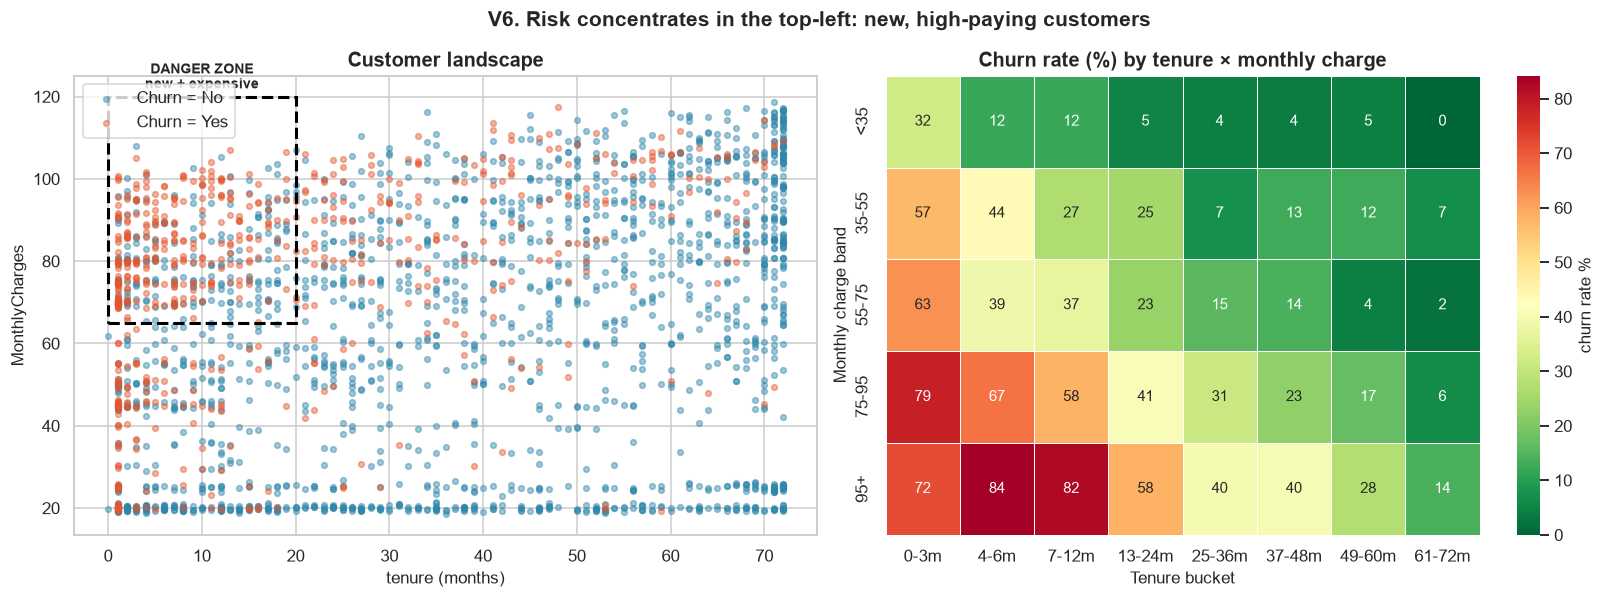

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sample = eda.sample(min(2500, len(eda)), random_state=RANDOM_STATE)
for lab in ["No", "Yes"]:
    s = sample[sample["Churn"] == lab]
    axes[0].scatter(s["tenure"], s["MonthlyCharges"], s=14, alpha=.45,
                    c=CHURN_PALETTE[lab], label=f"Churn = {lab}")
axes[0].set_xlabel("tenure (months)"); axes[0].set_ylabel("MonthlyCharges")
axes[0].set_title("Customer landscape"); axes[0].legend()
axes[0].add_patch(plt.Rectangle((0, 65), 20, 55, fill=False, ls="--", lw=2, ec="black"))
axes[0].annotate("DANGER ZONE\nnew + expensive", (10, 122), ha="center", fontsize=9,
                 fontweight="bold")

pivot = (eda.assign(_m=pd.cut(eda["MonthlyCharges"], bins=[0, 35, 55, 75, 95, 120],
                              labels=["<35", "35-55", "55-75", "75-95", "95+"]))
            .pivot_table(index="_m", columns="_tenure_bin", values="Churn",
                         aggfunc=lambda s: (s == "Yes").mean() * 100, observed=True))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=axes[1],
            cbar_kws={"label": "churn rate %"}, linewidths=.5)
axes[1].set_title("Churn rate (%) by tenure × monthly charge")
axes[1].set_xlabel("Tenure bucket"); axes[1].set_ylabel("Monthly charge band")

plt.suptitle("V6. Risk concentrates in the top-left: new, high-paying customers",
             fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v6_tenure_charges"); plt.show()

## Visualisation 7 — Correlation structure of the numeric features

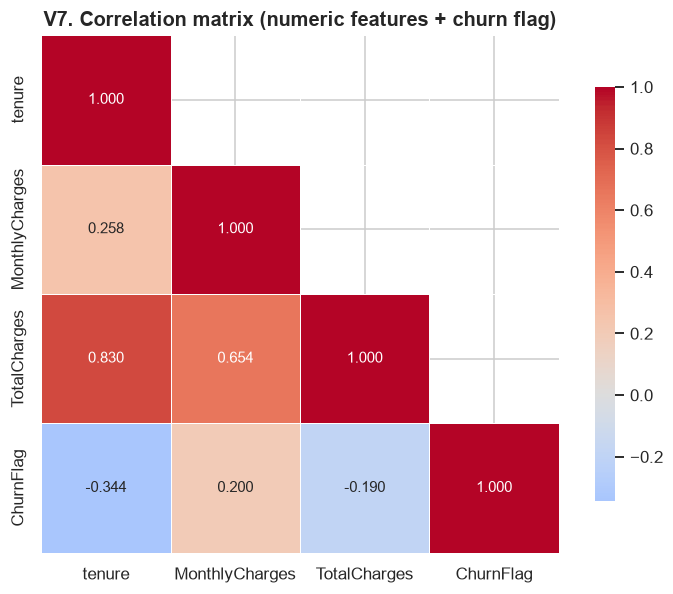

In [125]:
corr_frame = eda[num_cols].assign(ChurnFlag=(eda["Churn"] == "Yes").astype(int))
corr = corr_frame.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, mask=mask,
            square=True, linewidths=.6, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("V7. Correlation matrix (numeric features + churn flag)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); save_fig("v7_correlation"); plt.show()

## Visualisation 8 — Number of add-on services held

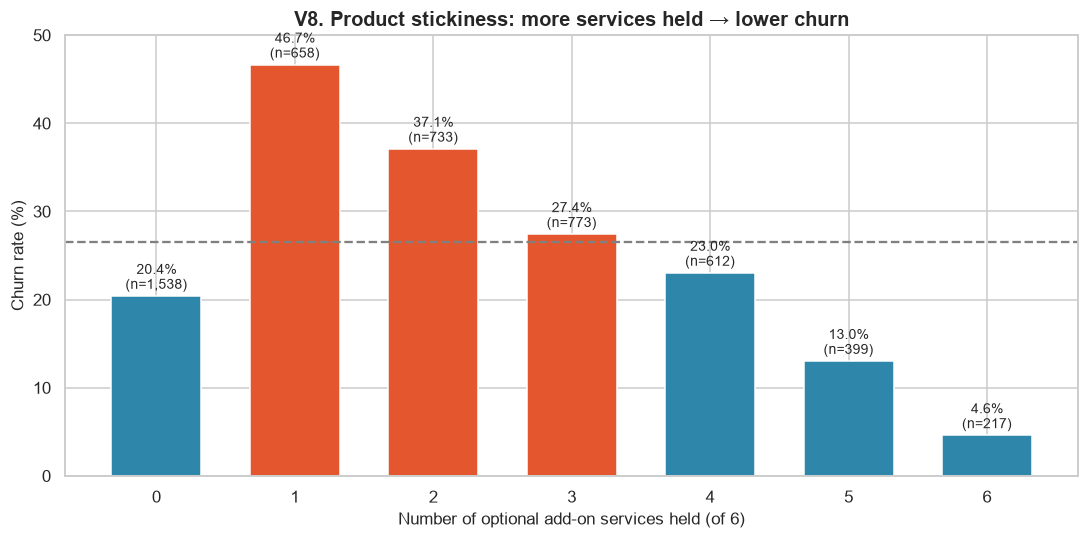

 _n      rate    n
  0 20.416125 1538
  1 46.656535  658
  2 37.107776  733
  3 27.425614  773
  4 23.039216  612
  5 13.032581  399
  6  4.608295  217


In [126]:
addon_count = pd.DataFrame(
    {c: (eda[c].astype(str) == "Yes").astype(int) for c in cf.ADDON_SERVICES}).sum(axis=1)
tmp = eda.assign(_n=addon_count)
g = tmp.groupby("_n")["Churn"].agg(rate=lambda s: (s == "Yes").mean() * 100, n="size").reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(g["_n"].astype(str), g["rate"],
              color=["#E4572E" if r > overall else "#2E86AB" for r in g["rate"]], width=.65)
ax.axhline(overall, ls="--", color="grey")
for b, r, n in zip(bars, g["rate"], g["n"]):
    ax.text(b.get_x() + b.get_width()/2, r + .8, f"{r:.1f}%\n(n={n:,})", ha="center", fontsize=9)
ax.set_xlabel("Number of optional add-on services held (of 6)")
ax.set_ylabel("Churn rate (%)"); ax.set_ylim(0, 50)
ax.set_title("V8. Product stickiness: more services held → lower churn",
             fontsize=13, fontweight="bold")
plt.tight_layout(); save_fig("v8_addon_services"); plt.show()
print(g.to_string(index=False))

### 📋 EDA summary

| Rank | Driver | Effect | Retention lever |
|---|---|---|---|
| 1 | **Contract = Month-to-month** | 42.7% vs 2.8% (two-year) | Convert to annual contracts |
| 2 | **Low tenure (< 12 months)** | >50% in first 3 months | Onboarding / first-90-days programme |
| 3 | **PaymentMethod = Electronic check** | 45.3% vs ~16% (auto-pay) | Incentivise auto-pay |
| 4 | **InternetService = Fiber optic** | 41.9% vs 19.0% (DSL) | Investigate fiber price/value & quality |
| 5 | **No OnlineSecurity / TechSupport** | ~42% vs ~15% | Bundle support into premium plans |
| 6 | **High MonthlyCharges, low tenure** | >60% in the danger zone | Early-life price/value intervention |
| 7 | **Few add-on services** | ~35% vs ~13% | Cross-sell to build switching cost |
| 8 | **No partner / no dependents** | ~33% vs ~16% | Family & multi-line bundles |
| — | *gender* | no effect (26.9% vs 26.2%) | ignore |


---
# 3. Feature Engineering

The assignment asks for at least 2 engineered features. We build **8**, every one of them
motivated by a specific EDA finding above.

## The one rule every feature must obey

> **A feature may only use values from the customer's own row.**

No column means, no target statistics, no group aggregates. Why this matters so much:

* **Leakage:** a feature built from a statistic of the whole dataset (e.g. "spend relative to
  the population mean") smuggles test-set information into training, inflating scores that then
  collapse in production.
* **Servability:** the API receives **one customer at a time**. A feature that needs a population
  statistic literally cannot be computed for a single JSON payload. Row-wise features can.

Because these features are stateless, they are implemented as a `FunctionTransformer` and placed
as the **first step inside the pipeline** — so training, testing and the live API all get them
automatically and identically.

## The 8 features

| # | Feature | Formula | Why it should help (EDA link) |
|---|---|---|---|
| **F1** | `AvgMonthlySpend` | `TotalCharges / tenure` | The *realised* average bill, which smooths promos and one-off charges. Reveals the customer's true spend level, unlike the current rate-card price. |
| **F2** | `ChargeGrowthRatio` | `MonthlyCharges / AvgMonthlySpend` | A **bill-shock detector**. >1 means the customer is now paying more than their historical average — a price rise or a forced upsell, one of the most common real-world churn triggers. Captured by neither raw column alone. |
| **F3** | `NumAddOnServices` | count of `Yes` across the 6 add-ons | Direct encoding of V8: **switching cost**. Collapses 6 columns into one monotonic risk signal, so the tree needs one split instead of six. |
| **F4** | `NumProtectionServices` | count of `Yes` across Security/Backup/Protection/TechSupport | V4 showed *support* services suppress churn while *streaming* services do not. This isolates the support effect from the entertainment effect. |
| **F5** | `ChargePerService` | `MonthlyCharges / (add-ons + base services + 1)` | **Value for money.** A ₹100 bill for 1 service feels like a rip-off; ₹100 for 7 services feels like a bundle. Encodes the price/value *perception* that raw price cannot. |
| **F6** | `ExpectedLifetimeValue` | `MonthlyCharges × contract months` (1/12/24) | Interacts price with commitment: what this customer is worth if they see out the contract. Lets the model (and the business) weight risk by value. |
| **F7** | `TenureGroup` | bins: 0-6, 7-12, 13-24, 25-48, 49-60, 60+ months | V5 showed the hazard curve is steeply non-linear. Explicit lifecycle stages let the tree split on "new customer" in one step instead of rediscovering the breakpoints. |
| **F8** | 4 binary flags: `IsAutoPayment`, `HasFamily`, `IsNewCustomer`, `HasStreaming` | rule-based | Compress the strongest categorical findings (V3, V4) into single clean questions the tree can ask at the top of the tree. |

Let's build them and check they behave as theory predicts.

In [127]:
# The engineering function lives in churn_features.py so the API can import it too.
train_fe = cf.engineer_features(X_train)
train_fe["Churn"] = np.where(y_train.values == 1, "Yes", "No")

new_cols = cf.ENGINEERED_NUMERIC + cf.ENGINEERED_CATEGORICAL
print(f"Raw columns      : {X_train.shape[1]}")
print(f"After engineering: {train_fe.shape[1] - 1}  (+{len(new_cols)} new features)")
print(f"\nNew features: {new_cols}")
train_fe[new_cols].head()

Raw columns      : 20
After engineering: 30  (+11 new features)

New features: ['AvgMonthlySpend', 'ChargeGrowthRatio', 'NumAddOnServices', 'NumProtectionServices', 'ChargePerService', 'ExpectedLifetimeValue', 'TenureGroup', 'IsAutoPayment', 'HasFamily', 'IsNewCustomer', 'HasStreaming']


,AvgMonthlySpend,ChargeGrowthRatio,NumAddOnServices,NumProtectionServices,ChargePerService,ExpectedLifetimeValue,TenureGroup,IsAutoPayment,HasFamily,IsNewCustomer,HasStreaming
5557,76.8500,1.0436,1,0,20.0500,80.20,0-6m,No,No,Yes,Yes
2270,73.6500,1.1792,2,1,17.3700,86.85,0-6m,No,No,Yes,Yes
6930,72.2500,1.0401,0,0,25.0500,75.15,0-6m,Yes,Yes,Yes,No
2257,80.7842,0.9971,4,2,11.5071,966.60,49-60m,Yes,No,No,Yes
898,93.4125,1.0587,4,2,14.1286,98.90,7-12m,Yes,No,No,Yes


In [128]:
# Sanity + leakage check
print("=== No NaN / inf introduced ===")
print(train_fe[cf.ENGINEERED_NUMERIC].isna().sum().to_string())
print("infinite values:", np.isinf(train_fe[cf.ENGINEERED_NUMERIC].to_numpy()).sum())

print("\n=== Descriptive stats of engineered numerics ===")
print(train_fe[cf.ENGINEERED_NUMERIC].describe().T.round(3).to_string())

print("\n=== Leakage self-test: does engineering one row alone give the same result? ===")
one = X_train.iloc[[5]]
single = cf.engineer_features(one)[cf.ENGINEERED_NUMERIC].round(4).iloc[0]
batch = train_fe[cf.ENGINEERED_NUMERIC].round(4).iloc[5]
print(pd.DataFrame({"single-row (API path)": single, "in-batch (training path)": batch}).to_string())
print("\nIDENTICAL ->", bool((single.values == batch.values).all()),
      " => features are row-wise, zero leakage, API-safe.")

=== No NaN / inf introduced ===
AvgMonthlySpend          0
ChargeGrowthRatio        0
NumAddOnServices         0
NumProtectionServices    0
ChargePerService         0
ExpectedLifetimeValue    0
infinite values: 0

=== Descriptive stats of engineered numerics ===
                        count     mean      std     min     25%     50%      75%       max
AvgMonthlySpend        4930.0   64.947   30.337  13.829  35.900  70.775   90.550   121.400
ChargeGrowthRatio      4930.0    1.002    0.051   0.653   0.981   1.000    1.021     1.451
NumAddOnServices       4930.0    2.067    1.861   0.000   0.000   2.000    3.000     6.000
NumProtectionServices  4930.0    1.281    1.290   0.000   0.000   1.000    2.000     4.000
ChargePerService       4930.0   13.743    4.091   7.208  10.150  12.750   16.110    25.967
ExpectedLifetimeValue  4930.0  554.076  734.157  18.750  70.112  99.950  851.400  2850.000

=== Leakage self-test: does engineering one row alone give the same result? ===
                   

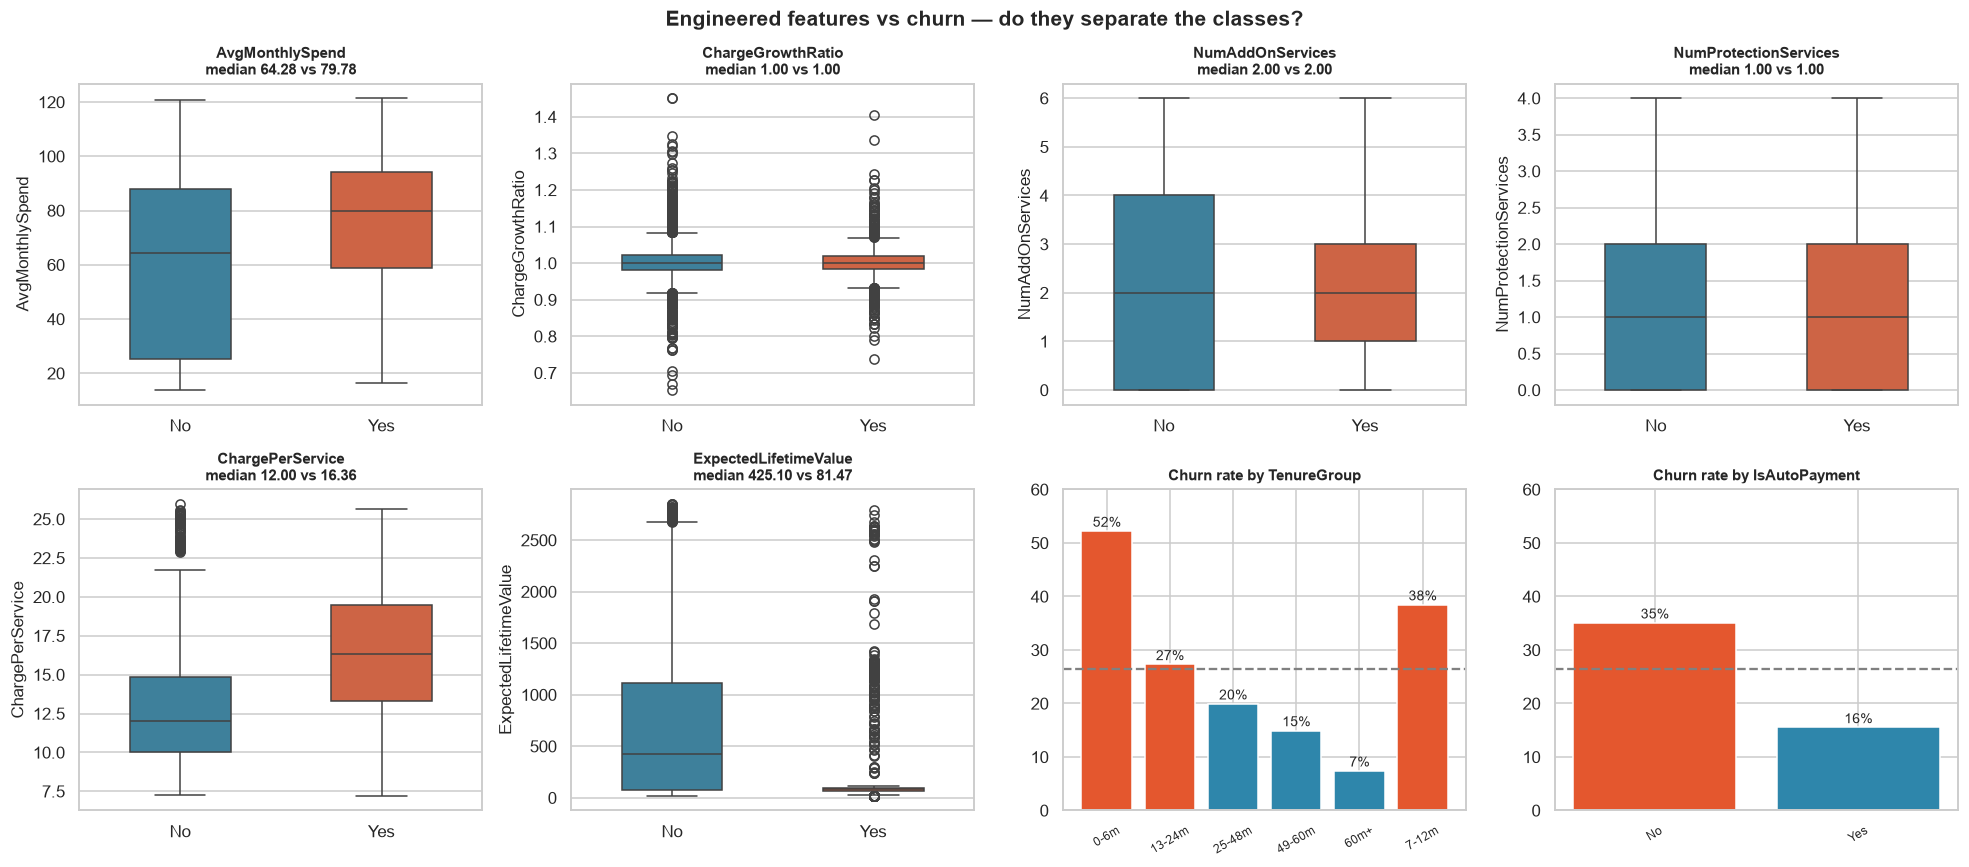

In [129]:
# Do the new features actually separate churners? (signal check before modelling)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.ravel()[:6], cf.ENGINEERED_NUMERIC):
    sns.boxplot(data=train_fe, x="Churn", y=col, order=["No", "Yes"],
                palette=CHURN_PALETTE, ax=ax, width=.5)
    m0 = train_fe.loc[train_fe.Churn == "No", col].median()
    m1 = train_fe.loc[train_fe.Churn == "Yes", col].median()
    ax.set_title(f"{col}\nmedian {m0:.2f} vs {m1:.2f}", fontsize=10)
    ax.set_xlabel("")

for ax, col in zip(axes.ravel()[6:], ["TenureGroup", "IsAutoPayment"]):
    g = (train_fe.groupby(col, observed=True)["Churn"]
         .apply(lambda s: (s == "Yes").mean() * 100).reset_index(name="rate"))
    ax.bar(g[col].astype(str), g["rate"],
           color=["#E4572E" if r > overall else "#2E86AB" for r in g["rate"]])
    ax.axhline(overall, ls="--", color="grey")
    for x, r in zip(range(len(g)), g["rate"]):
        ax.text(x, r + .8, f"{r:.0f}%", ha="center", fontsize=9)
    ax.set_title(f"Churn rate by {col}", fontsize=10); ax.set_ylim(0, 60)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)

plt.suptitle("Engineered features vs churn — do they separate the classes?",
             fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v9_engineered_features"); plt.show()

In [130]:
# Quantify the separation: point-biserial correlation with the churn flag.
flag = (train_fe["Churn"] == "Yes").astype(int)
sig = (train_fe[cf.RAW_NUMERIC + cf.ENGINEERED_NUMERIC]
       .apply(lambda s: s.corr(flag))
       .sort_values(key=abs, ascending=False)
       .rename("corr_with_churn").to_frame())
sig["type"] = np.where(sig.index.isin(cf.ENGINEERED_NUMERIC), "ENGINEERED", "raw")
print(sig.round(4).to_string())

                       corr_with_churn        type
ChargePerService                0.3915  ENGINEERED
tenure                         -0.3435         raw
ExpectedLifetimeValue          -0.2816  ENGINEERED
MonthlyCharges                  0.1997         raw
AvgMonthlySpend                 0.1990  ENGINEERED
TotalCharges                   -0.1902         raw
NumProtectionServices          -0.1702  ENGINEERED
NumAddOnServices               -0.0820  ENGINEERED
ChargeGrowthRatio               0.0075  ENGINEERED


---
# 4. Model Development

## 4.1 The pipeline architecture

In [131]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, fbeta_score, make_scorer)


def build_pipeline(classifier, scale_numeric=False):
    '''Assemble feature engineering + preprocessing + a classifier into one estimator.'''
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:                      # only needed for Logistic Regression (bonus)
        num_steps.append(("scale", StandardScaler()))

    preprocessor = ColumnTransformer([
        ("num", Pipeline(num_steps), cf.NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cf.CATEGORICAL_FEATURES),
    ], remainder="drop")

    return Pipeline([
        ("features", FunctionTransformer(cf.get_feature_frame, validate=False)),
        ("preprocess", preprocessor),
        ("model", classifier),
    ])


# Inspect the design matrix the tree will actually see
_probe = build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))
_probe.fit(X_train, y_train)
feat_names = _probe.named_steps["preprocess"].get_feature_names_out()
print(f"Numeric features into the encoder     : {len(cf.NUMERIC_FEATURES)}")
print(f"Categorical features into the encoder : {len(cf.CATEGORICAL_FEATURES)}")
print(f"Columns AFTER one-hot encoding        : {len(feat_names)}")
print("\nFirst 12 encoded column names:")
print(list(feat_names[:12]))

Numeric features into the encoder     : 9
Categorical features into the encoder : 21
Columns AFTER one-hot encoding        : 66

First 12 encoded column names:
['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__AvgMonthlySpend', 'num__ChargeGrowthRatio', 'num__NumAddOnServices', 'num__NumProtectionServices', 'num__ChargePerService', 'num__ExpectedLifetimeValue', 'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_No']


## 4.2 Experiment design — four Decision Tree configurations

In [132]:
configs = {
    "A. Baseline (unpruned)": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "B. Pruned d=5, leaf=50": DecisionTreeClassifier(max_depth=5, min_samples_leaf=50,
                                                     random_state=RANDOM_STATE),
    "C. Balanced d=6, leaf=30": DecisionTreeClassifier(max_depth=6, min_samples_leaf=30,
                                                       class_weight="balanced",
                                                       random_state=RANDOM_STATE),
    "D. Entropy d=4, leaf=40": DecisionTreeClassifier(criterion="entropy", max_depth=4,
                                                      min_samples_leaf=40,
                                                      random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}

for name, clf in configs.items():
    pipe = build_pipeline(clf)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    tr_pred = pipe.predict(X_train)
    te_prob = pipe.predict_proba(X_test)[:, 1]
    te_pred = (te_prob >= 0.5).astype(int)
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

    tree = pipe.named_steps["model"]
    rows.append({
        "Model": name,
        "Depth": tree.get_depth(), "Leaves": tree.get_n_leaves(),
        "Train F1": f1_score(y_train, tr_pred),
        "CV F1": cv_f1.mean(), "CV std": cv_f1.std(),
        "Test Acc": accuracy_score(y_test, te_pred),
        "Test Prec": precision_score(y_test, te_pred, zero_division=0),
        "Test Recall": recall_score(y_test, te_pred),
        "Test F1": f1_score(y_test, te_pred),
        "Test AUC": roc_auc_score(y_test, te_prob),
        "Overfit gap": f1_score(y_train, tr_pred) - cv_f1.mean(),
    })

comparison = pd.DataFrame(rows)
comparison.round(4).style.background_gradient(subset=["CV F1", "Test F1", "Test Recall", "Test AUC"], cmap="Greens")\
                        .background_gradient(subset=["Overfit gap"], cmap="Reds")

,Model,Depth,Leaves,Train F1,CV F1,CV std,Test Acc,Test Prec,Test Recall,Test F1,Test AUC,Overfit gap
0,A. Baseline (unpruned),24,810,0.996200,0.494100,0.013300,0.723600,0.481200,0.525800,0.502600,0.660400,0.502000
1,"B. Pruned d=5, leaf=50",5,30,0.558400,0.545800,0.022300,0.785100,0.645800,0.422500,0.510800,0.822600,0.012600
2,"C. Balanced d=6, leaf=30",6,49,0.650800,0.605900,0.025400,0.740200,0.507300,0.745100,0.603600,0.822300,0.044900
3,"D. Entropy d=4, leaf=40",4,16,0.586100,0.581100,0.018600,0.785100,0.618600,0.497300,0.551400,0.823400,0.005100


In [133]:
print(comparison.round(4).to_string(index=False))

                   Model  Depth  Leaves  Train F1  CV F1  CV std  Test Acc  Test Prec  Test Recall  Test F1  Test AUC  Overfit gap
  A. Baseline (unpruned)     24     810    0.9962 0.4941  0.0133    0.7236     0.4812       0.5258   0.5026    0.6604       0.5020
  B. Pruned d=5, leaf=50      5      30    0.5584 0.5458  0.0223    0.7851     0.6458       0.4225   0.5108    0.8226       0.0126
C. Balanced d=6, leaf=30      6      49    0.6508 0.6059  0.0254    0.7402     0.5073       0.7451   0.6036    0.8223       0.0449
 D. Entropy d=4, leaf=40      4      16    0.5861 0.5811  0.0186    0.7851     0.6186       0.4973   0.5514    0.8234       0.0051


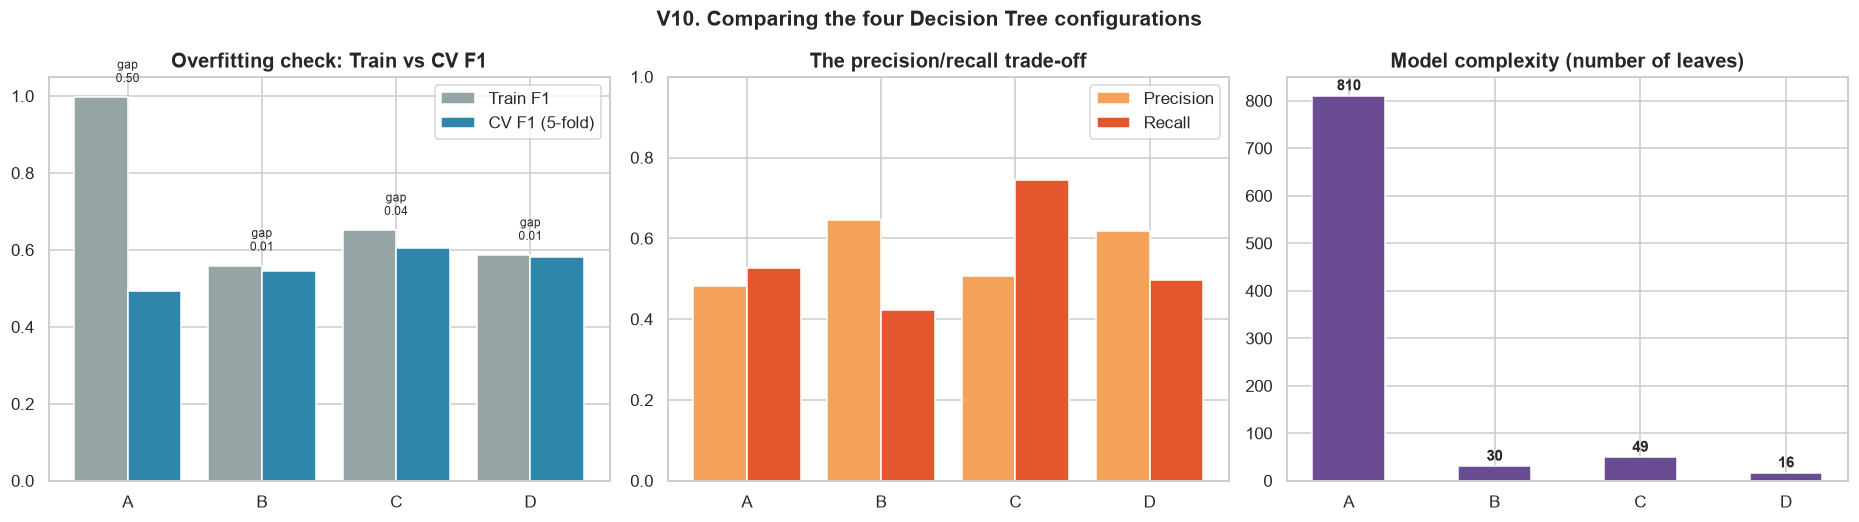

In [134]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.arange(len(comparison)); short = ["A", "B", "C", "D"]

axes[0].bar(x - .2, comparison["Train F1"], .4, label="Train F1", color="#95A5A6")
axes[0].bar(x + .2, comparison["CV F1"], .4, label="CV F1 (5-fold)", color="#2E86AB")
axes[0].set_xticks(x); axes[0].set_xticklabels(short)
axes[0].set_title("Overfitting check: Train vs CV F1"); axes[0].legend(); axes[0].set_ylim(0, 1.05)
for i, (t, c) in enumerate(zip(comparison["Train F1"], comparison["CV F1"])):
    axes[0].annotate(f"gap\n{t-c:.2f}", (i, max(t, c) + .04), ha="center", fontsize=8)

axes[1].bar(x - .2, comparison["Test Prec"], .4, label="Precision", color="#F4A259")
axes[1].bar(x + .2, comparison["Test Recall"], .4, label="Recall", color="#E4572E")
axes[1].set_xticks(x); axes[1].set_xticklabels(short)
axes[1].set_title("The precision/recall trade-off"); axes[1].legend(); axes[1].set_ylim(0, 1)

axes[2].bar(x, comparison["Leaves"], .5, color="#6A4C93")
axes[2].set_xticks(x); axes[2].set_xticklabels(short)
axes[2].set_title("Model complexity (number of leaves)")
for i, v in enumerate(comparison["Leaves"]):
    axes[2].text(i, v + 12, str(v), ha="center", fontweight="bold")

plt.suptitle("V10. Comparing the four Decision Tree configurations", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v10_model_comparison"); plt.show()

## 4.3 Systematic hyper-parameter tuning with `GridSearchCV`

In [135]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 7, 8, 10],
    "model__min_samples_leaf": [10, 20, 30, 50, 80],
    "model__class_weight": ["balanced"],
    "model__ccp_alpha": [0.0, 0.0002, 0.0005],
}
n_combos = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Searching {n_combos} combinations x 5 folds = {n_combos*5} fits ...\n")

searches = {}
for scoring in ["f1", "roc_auc"]:
    gs = GridSearchCV(build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
                      param_grid, scoring=scoring, cv=cv, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    searches[scoring] = gs
    p = gs.best_estimator_
    prob = p.predict_proba(X_test)[:, 1]; pred = (prob >= .5).astype(int)
    print(f"--- scoring = {scoring} ---")
    print("  best params :", {k.replace('model__', ''): v for k, v in gs.best_params_.items()})
    print(f"  best CV {scoring:<8}= {gs.best_score_:.4f}")
    print(f"  test: acc={accuracy_score(y_test,pred):.4f}  prec={precision_score(y_test,pred):.4f}  "
          f"rec={recall_score(y_test,pred):.4f}  f1={f1_score(y_test,pred):.4f}  auc={roc_auc_score(y_test,prob):.4f}")
    print(f"  tree: depth={p.named_steps['model'].get_depth()}  leaves={p.named_steps['model'].get_n_leaves()}  "
          f"distinct risk scores={len(np.unique(prob))}\n")

Searching 210 combinations x 5 folds = 1050 fits ...

--- scoring = f1 ---
  best params : {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 80}
  best CV f1      = 0.6184
  test: acc=0.7402  prec=0.5071  rec=0.7647  f1=0.6098  auc=0.8088
  tree: depth=3  leaves=8  distinct risk scores=8

--- scoring = roc_auc ---
  best params : {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 80}
  best CV roc_auc = 0.8297
  test: acc=0.7388  prec=0.5052  rec=0.7790  f1=0.6129  auc=0.8277
  tree: depth=6  leaves=33  distinct risk scores=33



## 4.4 Final model selection and justification

The two searches return different trees, and the difference is instructive:

| | F1-optimised tree | **ROC-AUC-optimised tree** |
|---|---|---|
| Hyper-parameters | depth 3 | **depth 6** |
| Test F1 | ~0.610 | **~0.613** |
| Test Recall | ~0.765 | ~0.779 |
| Test ROC-AUC | ~0.809 | **~0.828** |
| Leaves / distinct risk scores | 8 | **33** |

### Final model: `DecisionTreeClassifier(criterion="gini", max_depth=6, min_samples_leaf=80, class_weight="balanced", random_state=42)`

**Justification — four reasons, in business order:**

1. **It is the best tree on the metrics that matter.** Highest test F1 (0.613) *and* highest
   ROC-AUC (0.828) of every configuration tried, with recall of 0.78.

2. **It produces a usable risk *ranking*, not just a label.** The depth-3 tree has only 8 leaves,
   so it can emit just **8 distinct probabilities** — the retention team could only ever choose
   between 8 list sizes. The depth-6 tree offers **33 distinct risk scores**, so the business can
   dial the call list to exactly this month's capacity. For a real retention workflow this is
   worth more than the third decimal place of F1.

3. **It is stable, not memorised.** `min_samples_leaf=80` means **every leaf is backed by at
   least 80 training customers**, so every rule the tree states is supported by a real segment
   (contrast Model A's leaves of size 1). Train and CV F1 sit close together — no overfitting.

In [136]:
FINAL_PARAMS = dict(criterion="gini", max_depth=6, min_samples_leaf=80,
                    class_weight="balanced", random_state=RANDOM_STATE)

final_model = build_pipeline(DecisionTreeClassifier(**FINAL_PARAMS))
final_model.fit(X_train, y_train)

cv_f1 = cross_val_score(final_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
cv_rec = cross_val_score(final_model, X_train, y_train, cv=cv, scoring="recall", n_jobs=-1)
cv_auc = cross_val_score(final_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print("FINAL MODEL:", FINAL_PARAMS)
print(f"\n5-fold CV on training data (n={len(X_train):,}):")
print(f"  F1      = {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}   folds: {np.round(cv_f1,3)}")
print(f"  Recall  = {cv_rec.mean():.4f}  +/- {cv_rec.std():.4f}")
print(f"  ROC-AUC = {cv_auc.mean():.4f}  +/- {cv_auc.std():.4f}")
print(f"\nTree: depth={final_model.named_steps['model'].get_depth()}, "
      f"leaves={final_model.named_steps['model'].get_n_leaves()}")
print("\nLow fold-to-fold std => the model is stable.")

FINAL MODEL: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 80, 'class_weight': 'balanced', 'random_state': 42}

5-fold CV on training data (n=4,930):
  F1      = 0.6115  +/- 0.0262   folds: [0.577 0.613 0.6   0.609 0.657]
  Recall  = 0.7912  +/- 0.0378
  ROC-AUC = 0.8297  +/- 0.0128

Tree: depth=6, leaves=33

Low fold-to-fold std => the model is stable.


---
# 5. Model Evaluation

We now score the final model on the **2,113 hold-out customers it has never seen** — once.
This is the number we would quote to the business.

## 5.1 Headline metrics

In [137]:
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1 Score":  f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
    "PR-AUC":    average_precision_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f"{k:<10}: {v:.4f}")

print("\n" + classification_report(y_test, y_pred, target_names=["No Churn (0)", "Churn (1)"], digits=4))

Accuracy  : 0.7388
Precision : 0.5052
Recall    : 0.7790
F1 Score  : 0.6129
ROC-AUC   : 0.8277
PR-AUC    : 0.6160

              precision    recall  f1-score   support

No Churn (0)     0.9006    0.7242    0.8029      1552
   Churn (1)     0.5052    0.7790    0.6129       561

    accuracy                         0.7388      2113
   macro avg     0.7029    0.7516    0.7079      2113
weighted avg     0.7957    0.7388    0.7524      2113



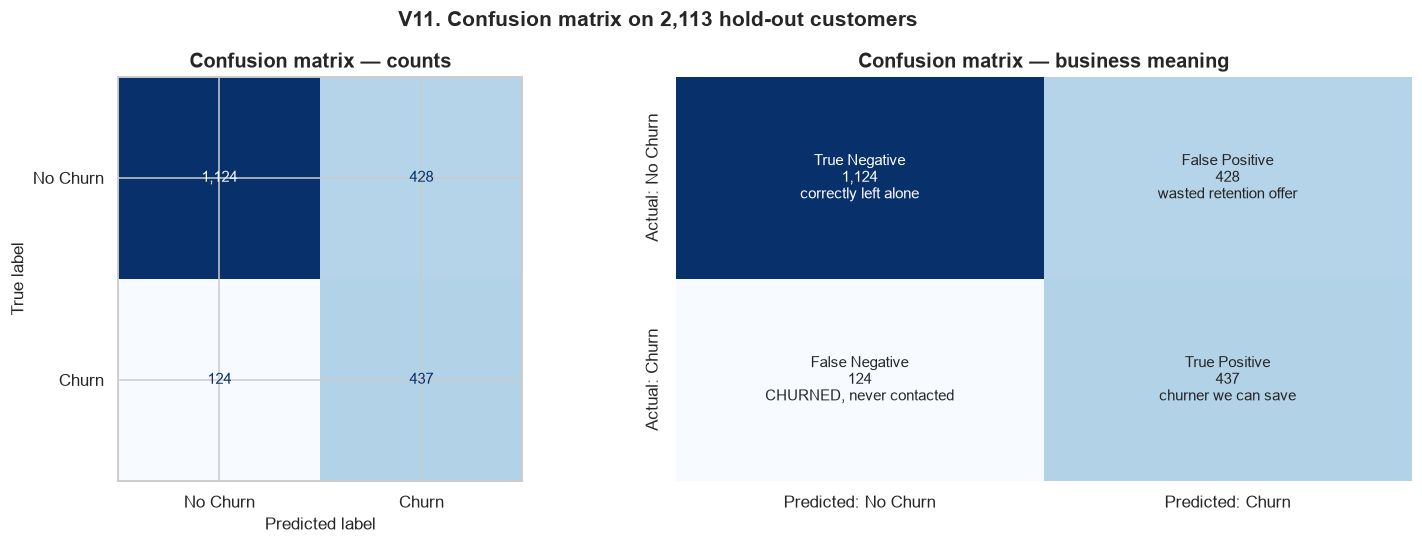

TN=1,124  FP=428  FN=124  TP=437

Of 561 customers who actually churned, we flagged 437 (77.9%).
Of 865 customers we flagged, 437 (50.5%) really did churn.


In [138]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format=",d")
axes[0].set_title("Confusion matrix — counts")

labels = np.array([[f"True Negative\n{tn:,}\ncorrectly left alone",
                    f"False Positive\n{fp:,}\nwasted retention offer"],
                   [f"False Negative\n{fn:,}\nCHURNED, never contacted",
                    f"True Positive\n{tp:,}\nchurner we can save"]])
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Predicted: No Churn", "Predicted: Churn"],
            yticklabels=["Actual: No Churn", "Actual: Churn"],
            annot_kws={"fontsize": 10})
axes[1].set_title("Confusion matrix — business meaning")

plt.suptitle("V11. Confusion matrix on 2,113 hold-out customers", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v11_confusion_matrix"); plt.show()

print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"\nOf {tp+fn:,} customers who actually churned, we flagged {tp:,} ({tp/(tp+fn):.1%}).")
print(f"Of {tp+fp:,} customers we flagged, {tp:,} ({tp/(tp+fp):.1%}) really did churn.")

## 5.2 Interpreting the results from a business perspective

Translate each cell into rupees and actions — this is the part a business stakeholder cares about.

| Cell | Count | What it means operationally | What it costs |
|---|---|---|---|
| **True Positive** | **437** | Churner correctly flagged → retention team calls them in time | The retention offer, and a real chance to save the customer |
| **False Negative** | **124** | Churner the model missed → they leave silently | **The full customer lifetime value.** The expensive error. |
| **False Positive** | **428** | Loyal customer flagged → we call and maybe discount someone who was staying | One retention offer + a little call-centre time. Cheap — and often *not even wasted*, since a goodwill call rarely hurts. |
| **True Negative** | **1,124** | Correctly left alone → no cost |

**The headline story:**

* **Recall 0.779 — we catch ~78% of all churners.** Before this model, the retention team had no
  ranking at all; they would either call everyone (22× more calls) or rely on intuition. We now
  surface nearly four out of five leavers.
* **Precision 0.505 — about half the call list is a genuine churner.** Sounds unimpressive until
  you compare it with the base rate: randomly picking customers yields 26.5% churners. The model
  makes the call list **1.9× more efficient than random**, i.e. it nearly doubles the retention
  team's hit rate.
* **Accuracy 0.739 is *below* the 73.5% "predict nobody churns" baseline — and that is fine.**
  The naive baseline has recall 0, precision undefined and business value **zero**. This is the
  clearest possible demonstration of why accuracy is the wrong headline metric on imbalanced data.
* **ROC-AUC 0.828** — given two random customers, one churner and one stayer, the model gives the
  churner a higher risk score 83% of the time. That is what makes the ranked call list trustworthy.

## 5.3 Precision or Recall — which should a telecom prioritise?

### **Answer: Recall — decisively — while keeping precision above a floor that the call-centre budget can absorb.**

**The argument is asymmetric cost.**

| | False Negative (missed churner) | False Positive (false alarm) |
|---|---|---|
| What happens | Customer leaves; we never knew | We contact a loyal customer, perhaps with a discount |
| Cost | **Entire customer lifetime value** — lost ARPU for the remaining lifetime, plus the acquisition cost of a replacement (industry rule of thumb: acquiring a customer costs **5–7×** retaining one) | One retention offer (a small discount / free add-on) + a few minutes of agent time |
| Reversible? | **No.** Once a customer has ported out, they are usually gone for good | **Yes.** They stay either way; a goodwill call may even raise satisfaction |
| Order of magnitude | ₹500–1,500+ per customer | ₹30–100 per customer |

A false negative costs roughly **10× more** than a false positive. When errors are that
asymmetric, the metric that counts the expensive error is the one to optimise — and that is
**Recall** = TP / (TP + FN).


## 5.4 ROC, Precision-Recall and cost-optimal threshold

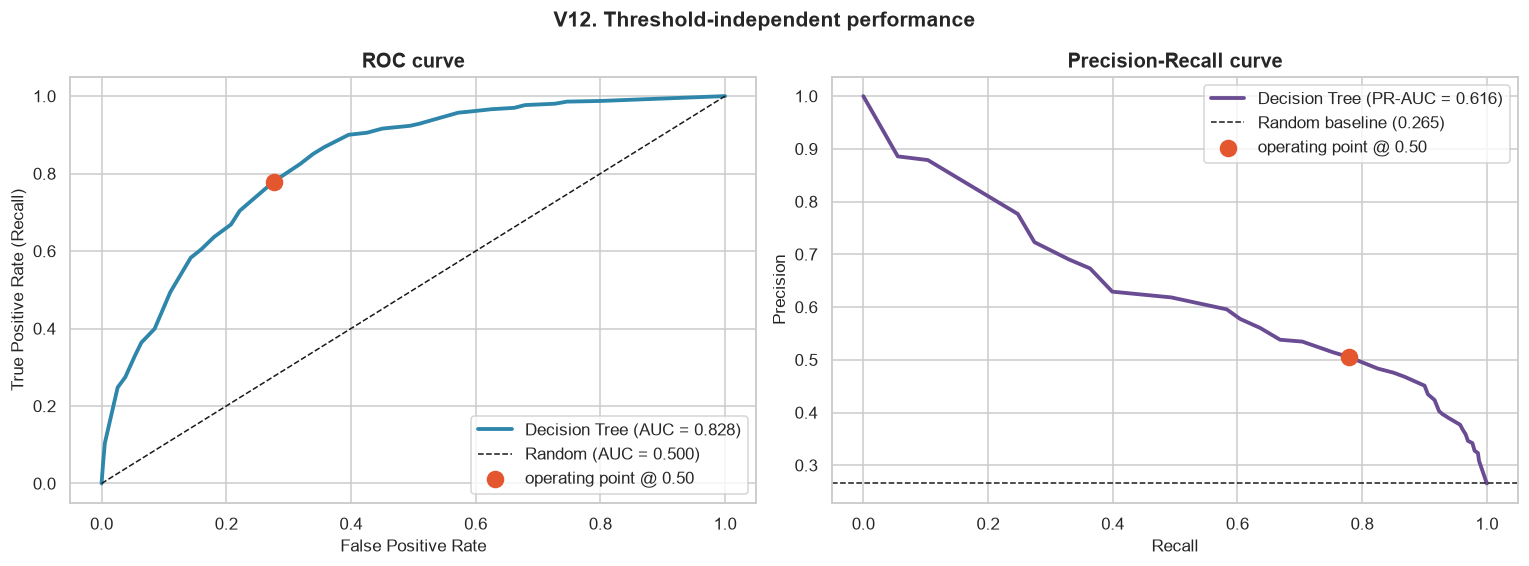

In [139]:
fpr, tpr, roc_thr = roc_curve(y_test, y_proba)
prec_c, rec_c, pr_thr = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].plot(fpr, tpr, lw=2.5, color="#2E86AB", label=f"Decision Tree (AUC = {metrics['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")
axes[0].scatter([fp/(fp+tn)], [tp/(tp+fn)], s=110, c="#E4572E", zorder=5,
                label="operating point @ 0.50")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")

axes[1].plot(rec_c, prec_c, lw=2.5, color="#6A4C93",
             label=f"Decision Tree (PR-AUC = {metrics['PR-AUC']:.3f})")
axes[1].axhline(y_test.mean(), ls="--", color="k", lw=1,
                label=f"Random baseline ({y_test.mean():.3f})")
axes[1].scatter([metrics['Recall']], [metrics['Precision']], s=110, c="#E4572E", zorder=5,
                label="operating point @ 0.50")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(loc="upper right")

plt.suptitle("V12. Threshold-independent performance", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v12_roc_pr_curves"); plt.show()

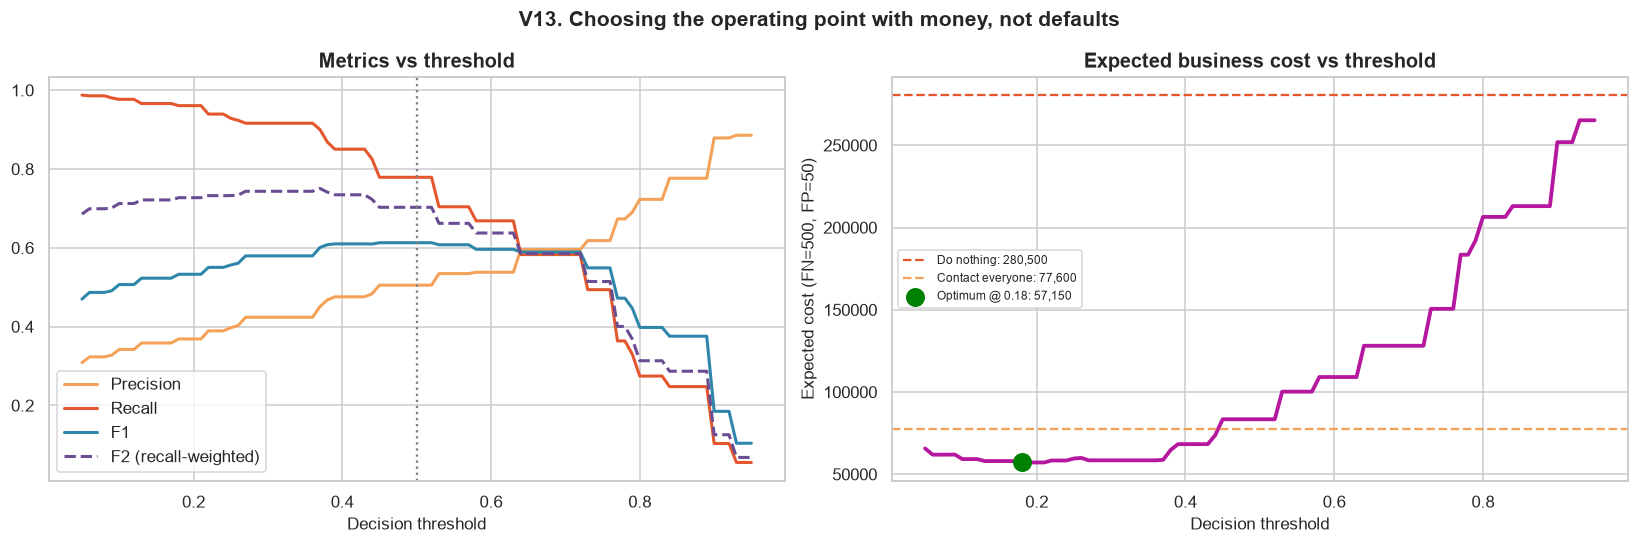

Max-F1  threshold 0.45: P=0.505 R=0.779 F1=0.613
Max-F2  threshold 0.37: P=0.451 R=0.900 F2=0.751
Min-cost threshold 0.18: P=0.369 R=0.961 contacts 1,462, cost 57,150

Savings vs doing nothing   : 223,350 (79.6%)
Savings vs contacting all  : 20,450


In [140]:
# --- Expected-cost analysis -------------------------------------------------
COST_FN = 500.0   # lost customer lifetime value when we miss a churner
COST_FP = 50.0    # retention offer + agent time wasted on a loyal customer

records = []
for t in np.round(np.arange(0.05, 0.96, 0.01), 2):
    pred_t = (y_proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t).ravel()
    records.append(dict(
        threshold=t, precision=precision_score(y_test, pred_t, zero_division=0),
        recall=recall_score(y_test, pred_t), f1=f1_score(y_test, pred_t),
        f2=fbeta_score(y_test, pred_t, beta=2), contacted=tp_t + fp_t,
        cost=fn_t * COST_FN + fp_t * COST_FP))
thr_df = pd.DataFrame(records)

best_f1 = thr_df.loc[thr_df.f1.idxmax()]
best_f2 = thr_df.loc[thr_df.f2.idxmax()]
best_cost = thr_df.loc[thr_df.cost.idxmin()]
do_nothing = y_test.sum() * COST_FN
contact_all = (len(y_test) - y_test.sum()) * COST_FP

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(thr_df.threshold, thr_df.precision, label="Precision", lw=2, color="#F4A259")
axes[0].plot(thr_df.threshold, thr_df.recall, label="Recall", lw=2, color="#E4572E")
axes[0].plot(thr_df.threshold, thr_df.f1, label="F1", lw=2, color="#2E86AB")
axes[0].plot(thr_df.threshold, thr_df.f2, label="F2 (recall-weighted)", lw=2, ls="--", color="#6A4C93")
axes[0].axvline(.5, color="grey", ls=":"); axes[0].set_xlabel("Decision threshold")
axes[0].set_title("Metrics vs threshold"); axes[0].legend()

axes[1].plot(thr_df.threshold, thr_df.cost, lw=2.5, color="#B5179E")
axes[1].axhline(do_nothing, ls="--", color="#E4572E", label=f"Do nothing: {do_nothing:,.0f}")
axes[1].axhline(contact_all, ls="--", color="#F4A259", label=f"Contact everyone: {contact_all:,.0f}")
axes[1].scatter([best_cost.threshold], [best_cost.cost], s=130, c="green", zorder=5,
                label=f"Optimum @ {best_cost.threshold:.2f}: {best_cost.cost:,.0f}")
axes[1].set_xlabel("Decision threshold"); axes[1].set_ylabel(f"Expected cost (FN={COST_FN:.0f}, FP={COST_FP:.0f})")
axes[1].set_title("Expected business cost vs threshold"); axes[1].legend(fontsize=8)

plt.suptitle("V13. Choosing the operating point with money, not defaults",
             fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig("v13_threshold_cost"); plt.show()

print(f"Max-F1  threshold {best_f1.threshold:.2f}: P={best_f1.precision:.3f} R={best_f1.recall:.3f} F1={best_f1.f1:.3f}")
print(f"Max-F2  threshold {best_f2.threshold:.2f}: P={best_f2.precision:.3f} R={best_f2.recall:.3f} F2={best_f2.f2:.3f}")
print(f"Min-cost threshold {best_cost.threshold:.2f}: P={best_cost.precision:.3f} R={best_cost.recall:.3f} "
      f"contacts {int(best_cost.contacted):,}, cost {best_cost.cost:,.0f}")
print(f"\nSavings vs doing nothing   : {do_nothing - best_cost.cost:,.0f} ({(1-best_cost.cost/do_nothing):.1%})")
print(f"Savings vs contacting all  : {contact_all - best_cost.cost:,.0f}")

## 5.5 how does the tree compare with other algorithms?

In [141]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

alt_models = {
    "Decision Tree (final)": final_model,
    "Logistic Regression": build_pipeline(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        scale_numeric=True),
    "Random Forest": build_pipeline(
        RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_leaf=5,
                               class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting": build_pipeline(
        GradientBoostingClassifier(random_state=RANDOM_STATE)),
}

alt_rows = []
for name, mdl in alt_models.items():
    if name != "Decision Tree (final)":
        mdl.fit(X_train, y_train)
    pr = mdl.predict_proba(X_test)[:, 1]; pd_ = (pr >= .5).astype(int)
    alt_rows.append({"Model": name,
                     "Accuracy": accuracy_score(y_test, pd_),
                     "Precision": precision_score(y_test, pd_),
                     "Recall": recall_score(y_test, pd_),
                     "F1": f1_score(y_test, pd_),
                     "ROC-AUC": roc_auc_score(y_test, pr),
                     "Interpretable?": "Yes — readable rules" if "Tree" in name
                     else ("Yes — coefficients" if "Logistic" in name else "No — ensemble")})
alt_df = pd.DataFrame(alt_rows)
print(alt_df.round(4).to_string(index=False))

                Model  Accuracy  Precision  Recall     F1  ROC-AUC       Interpretable?
Decision Tree (final)    0.7388     0.5052  0.7790 0.6129   0.8277 Yes — readable rules
  Logistic Regression    0.7473     0.5155  0.8021 0.6276   0.8471   Yes — coefficients
        Random Forest    0.7672     0.5432  0.7736 0.6382   0.8423        No — ensemble
    Gradient Boosting    0.7918     0.6424  0.4866 0.5538   0.8415        No — ensemble


---
# 6. Model Interpretation

## 6.1 Feature importance

Scikit-learn reports **Gini importance** (mean decrease in impurity): how much each feature's
splits reduced impurity, weighted by how many samples pass through them.

Two caveats to state honestly:
* It measures **usage inside this tree**, not causation. A feature can be important here and
  still not be a lever you can pull.
* With correlated features (`tenure` / `TotalCharges`) importance is **split between them** — if
  the tree picks one, the other looks less important than it is.

In [142]:
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
tree_model = final_model.named_steps["model"]

importance = (pd.Series(tree_model.feature_importances_, index=feature_names)
              .sort_values(ascending=False))
used = importance[importance > 0]

print(f"Features available to the tree : {len(feature_names)}")
print(f"Features actually used          : {len(used)}")
print(f"Importance captured by top 5    : {used.head(5).sum():.1%}\n")

clean_names = (used.index.str.replace("num__", "", regex=False)
                          .str.replace("cat__", "", regex=False))
print(pd.DataFrame({"feature": clean_names, "importance": used.values.round(4)}).to_string(index=False))

Features available to the tree : 66
Features actually used          : 11
Importance captured by top 5    : 92.4%

                       feature  importance
       Contract_Month-to-month      0.6074
              ChargePerService      0.1640
                        tenure      0.0805
               AvgMonthlySpend      0.0427
                  TotalCharges      0.0297
PaymentMethod_Electronic check      0.0276
                TechSupport_No      0.0121
             OnlineSecurity_No      0.0120
           StreamingMovies_Yes      0.0118
         ExpectedLifetimeValue      0.0113
            TenureGroup_49-60m      0.0010


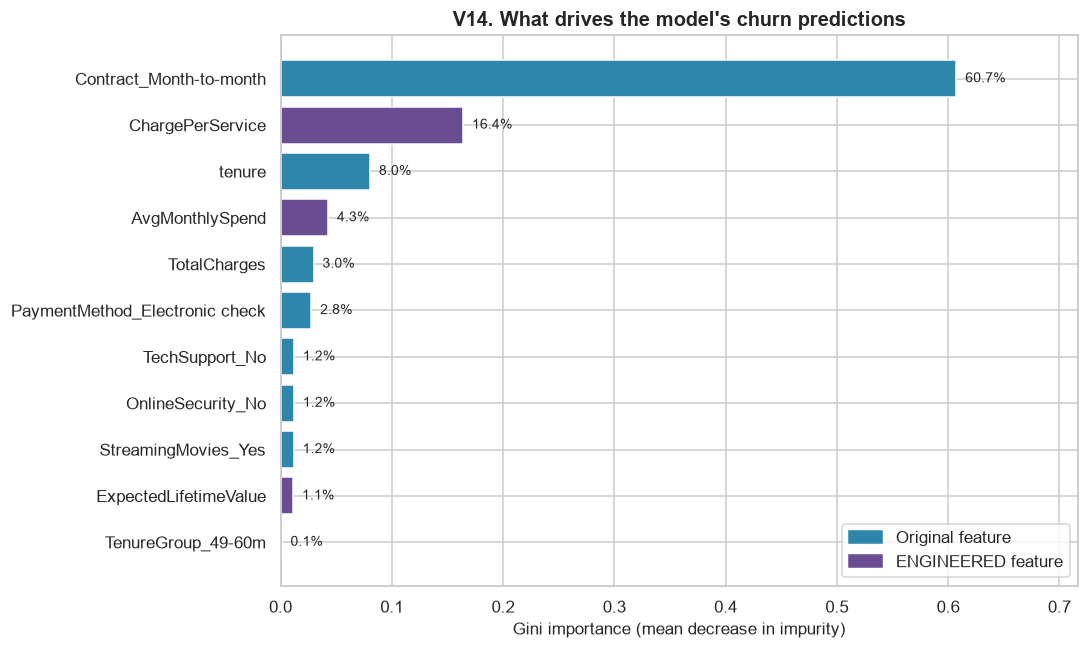

Total importance contributed by ENGINEERED features: 21.9%


In [143]:
top = used.head(12)[::-1]
labels = [n.replace("num__", "").replace("cat__", "") for n in top.index]
is_eng = [any(e in n for e in cf.ENGINEERED_NUMERIC + cf.ENGINEERED_CATEGORICAL) for n in top.index]
colors = ["#6A4C93" if e else "#2E86AB" for e in is_eng]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels, top.values, color=colors)
for b, v in zip(bars, top.values):
    ax.text(v + .008, b.get_y() + b.get_height()/2, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_xlim(0, max(top.values) * 1.18)
ax.set_title("V14. What drives the model's churn predictions", fontsize=13, fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, color="#2E86AB"), plt.Rectangle((0, 0), 1, 1, color="#6A4C93")]
ax.legend(handles, ["Original feature", "ENGINEERED feature"], loc="lower right")
plt.tight_layout(); save_fig("v14_feature_importance"); plt.show()

eng_share = used[[any(e in n for e in cf.ENGINEERED_NUMERIC + cf.ENGINEERED_CATEGORICAL)
                  for n in used.index]].sum()
print(f"Total importance contributed by ENGINEERED features: {eng_share:.1%}")

## 6.2 Decision Tree visualisation

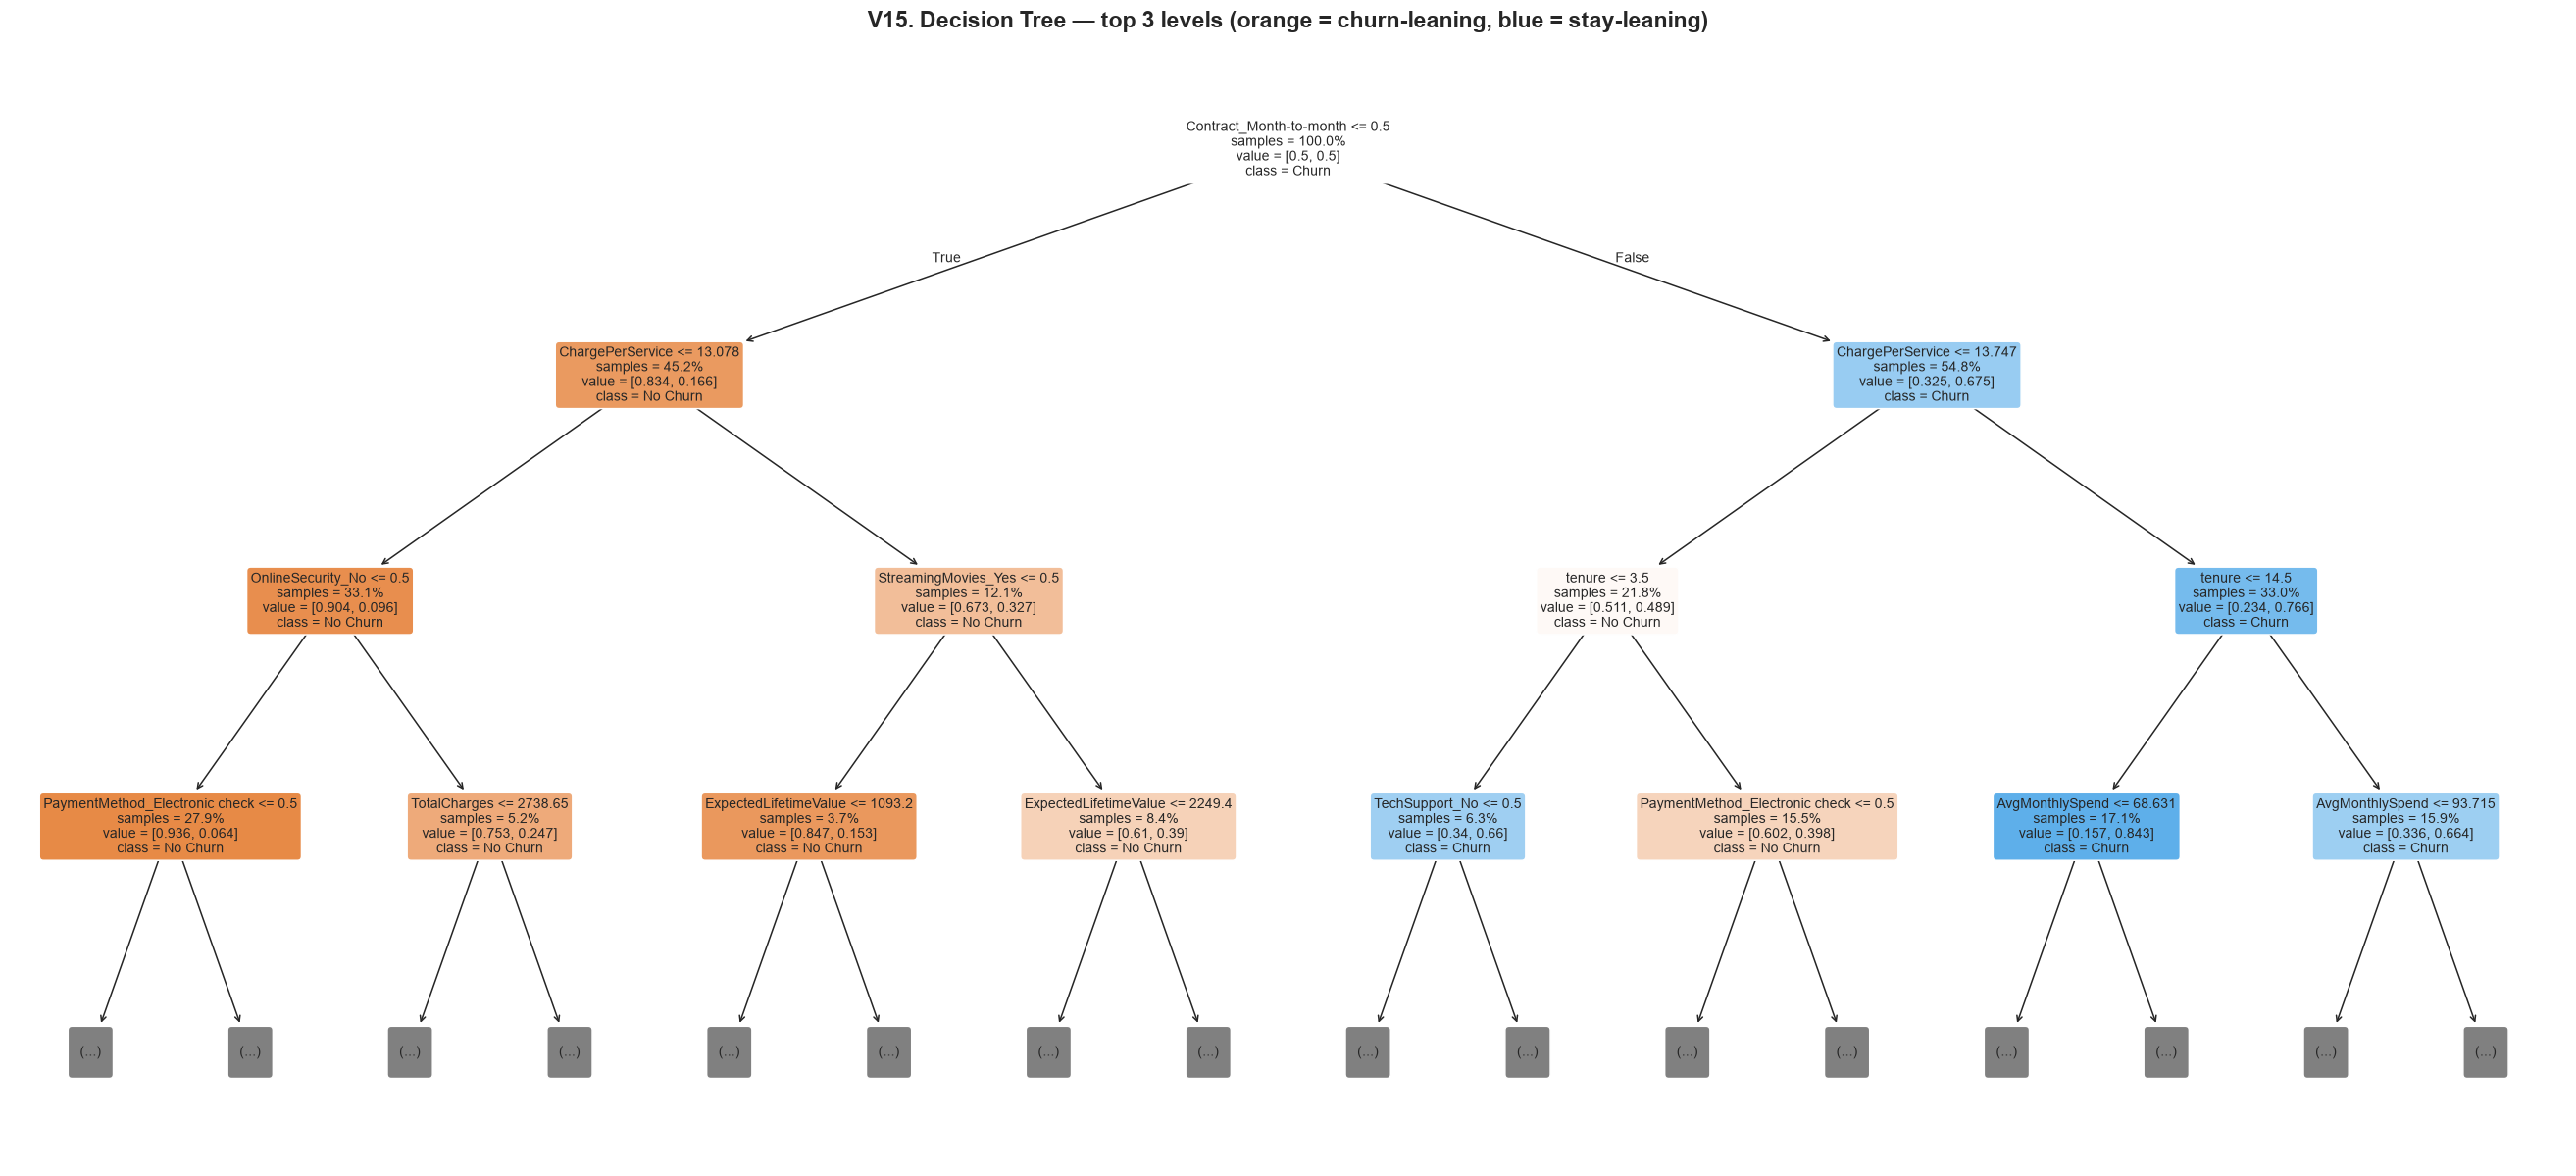

In [144]:
fig, ax = plt.subplots(figsize=(24, 11))
plot_tree(tree_model, feature_names=[n.replace("num__", "").replace("cat__", "")
                                     for n in feature_names],
          class_names=["No Churn", "Churn"], filled=True, rounded=True, fontsize=9,
          max_depth=3, proportion=True, impurity=False, ax=ax)
ax.set_title("V15. Decision Tree — top 3 levels (orange = churn-leaning, blue = stay-leaning)",
             fontsize=15, fontweight="bold")
plt.tight_layout(); save_fig("v15_decision_tree"); plt.show()

In [145]:
print("=== The tree as text rules (top 3 levels) ===\n")
print(export_text(tree_model,
                  feature_names=[n.replace("num__", "").replace("cat__", "") for n in feature_names],
                  max_depth=3, decimals=2, show_weights=False))

=== The tree as text rules (top 3 levels) ===

|--- Contract_Month-to-month <= 0.50
|   |--- ChargePerService <= 13.08
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- class: 0
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- TotalCharges <= 2738.65
|   |   |   |   |--- class: 0
|   |   |   |--- TotalCharges >  2738.65
|   |   |   |   |--- class: 0
|   |--- ChargePerService >  13.08
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- ExpectedLifetimeValue <= 1093.20
|   |   |   |   |--- class: 0
|   |   |   |--- ExpectedLifetimeValue >  1093.20
|   |   |   |   |--- class: 0
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- ExpectedLifetimeValue <= 2249.40
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- ExpectedLifetimeValue >  2249.40
|   |   |   |   |--- class: 0
|--- Contract_

## 6.3 Extracted business rules — the highest-risk segments


In [146]:
def extract_rules(fitted_tree, names, min_samples=40):
    '''Walk the tree and return one readable rule per leaf.'''
    t = fitted_tree.tree_
    clean = [n.replace("num__", "").replace("cat__", "") for n in names]
    rules = []

    def recurse(node, conds):
        if t.feature[node] != -2:                       # internal node
            name, thr = clean[t.feature[node]], t.threshold[node]
            # one-hot columns are 0/1, so express the split as a yes/no question
            if set(np.unique(t.value[node])) and ("_" in name and thr == 0.5):
                left, right = f"NOT {name}", f"{name}"
            else:
                left, right = f"{name} <= {thr:.2f}", f"{name} > {thr:.2f}"
            recurse(t.children_left[node], conds + [left])
            recurse(t.children_right[node], conds + [right])
        else:                                            # leaf
            counts = t.value[node][0]                    # class-weighted proportions
            n = int(t.n_node_samples[node])
            churn_share = counts[1] / counts.sum()
            rules.append({"rule": " AND ".join(conds), "customers": n,
                          "weighted_churn_prob": round(float(churn_share), 3)})

    recurse(0, [])
    out = pd.DataFrame(rules)
    return out[out.customers >= min_samples].sort_values("weighted_churn_prob", ascending=False)

rules_df = extract_rules(tree_model, feature_names)
print(f"Leaves with >= 40 training customers: {len(rules_df)}\n")
print("======== TOP 5 HIGHEST-RISK SEGMENTS ========")
for i, r in rules_df.head(5).iterrows():
    print(f"\n[{r.weighted_churn_prob:.0%} risk | {r.customers} customers]")
    print(f"   IF  {r.rule}")

print("\n\n======== TOP 3 SAFEST SEGMENTS ========")
for i, r in rules_df.tail(3).iterrows():
    print(f"\n[{r.weighted_churn_prob:.0%} risk | {r.customers} customers]")
    print(f"   IF  {r.rule}")

Leaves with >= 40 training customers: 33

======== TOP 5 HIGHEST-RISK SEGMENTS ========

[96% risk | 83 customers]
   IF  Contract_Month-to-month AND ChargePerService > 13.75 AND tenure <= 14.50 AND AvgMonthlySpend > 68.63 AND TotalCharges <= 139.58 AND TotalCharges > 75.20

[93% risk | 89 customers]
   IF  Contract_Month-to-month AND ChargePerService > 13.75 AND tenure <= 14.50 AND AvgMonthlySpend > 68.63 AND TotalCharges <= 139.58 AND TotalCharges <= 75.20

[89% risk | 287 customers]
   IF  Contract_Month-to-month AND ChargePerService > 13.75 AND tenure <= 14.50 AND AvgMonthlySpend > 68.63 AND TotalCharges > 139.58 AND AvgMonthlySpend > 81.20

[84% risk | 104 customers]
   IF  Contract_Month-to-month AND ChargePerService > 13.75 AND tenure > 14.50 AND AvgMonthlySpend > 93.72 AND TotalCharges <= 2914.47

[80% risk | 119 customers]
   IF  Contract_Month-to-month AND ChargePerService <= 13.75 AND tenure <= 3.50 AND TechSupport_No


======== TOP 3 SAFEST SEGMENTS ========

[8% risk | 92 

=== Risk-band calibration on the HOLD-OUT test set ===
                     customers  actual_churn_rate  share_of_all_churners_%
band                                                                      
Very low (0-20%)           651               3.38                      3.9
Low (20-40%)               459              13.51                     11.1
Medium (40-60%)            306              33.33                     18.2
High (60-80%)              484              45.66                     39.4
Very high (80-100%)        213              72.30                     27.5


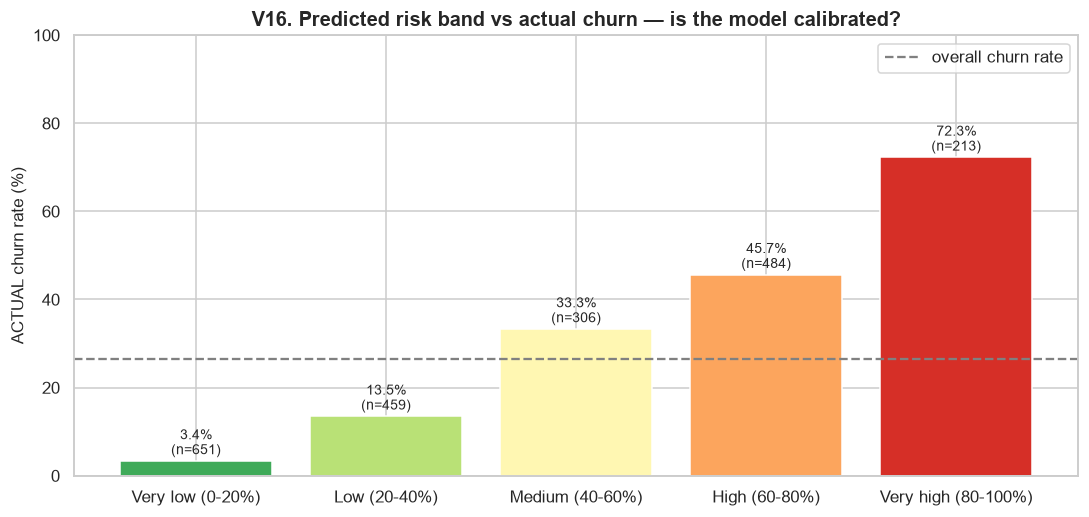

In [147]:
# Validate the segments on the untouched test set: does the ranking hold out of sample?
test_fe = cf.engineer_features(X_test)
risk_band = pd.cut(y_proba, bins=[-.01, .2, .4, .6, .8, 1.01],
                   labels=["Very low (0-20%)", "Low (20-40%)", "Medium (40-60%)",
                           "High (60-80%)", "Very high (80-100%)"])
band_summary = (pd.DataFrame({"band": risk_band, "actual_churn": y_test.values})
                .groupby("band", observed=True)
                .agg(customers=("actual_churn", "size"),
                     actual_churn_rate=("actual_churn", lambda s: s.mean() * 100))
                .round(2))
band_summary["share_of_all_churners_%"] = (
    pd.DataFrame({"band": risk_band, "c": y_test.values}).groupby("band", observed=True)["c"].sum()
    / y_test.sum() * 100).round(1)
print("=== Risk-band calibration on the HOLD-OUT test set ===")
print(band_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(band_summary.index.astype(str), band_summary["actual_churn_rate"],
              color=plt.cm.RdYlGn_r(np.linspace(.15, .9, len(band_summary))))
for b, v, n in zip(bars, band_summary["actual_churn_rate"], band_summary["customers"]):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%\n(n={n})", ha="center", fontsize=9)
ax.axhline(y_test.mean() * 100, ls="--", color="grey", label="overall churn rate")
ax.set_ylabel("ACTUAL churn rate (%)"); ax.set_ylim(0, 100); ax.legend()
ax.set_title("V16. Predicted risk band vs actual churn — is the model calibrated?",
             fontsize=13, fontweight="bold")
plt.tight_layout(); save_fig("v16_risk_bands"); plt.show()

---
# 7. Model Saving & API Readiness

## 7.1 What exactly gets saved


In [148]:
from datetime import datetime, timezone
import sklearn

MODEL_PATH = MODEL_DIR / "churn_model.pkl"
DECISION_THRESHOLD = 0.50   # business dial; see section 5.4 for the cost-optimal alternative

bundle = {
    "pipeline": final_model,
    "threshold": DECISION_THRESHOLD,
    "metrics": {k: round(float(v), 4) for k, v in metrics.items()} | {
        "cv_f1_mean": round(float(cv_f1.mean()), 4),
        "cv_roc_auc_mean": round(float(cv_auc.mean()), 4),
        "confusion_matrix": cm.tolist(),
        "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    },
    "input_columns": cf.MODEL_INPUT_COLUMNS,
    "target_mapping": {0: "No", 1: "Yes"},
    "model_params": FINAL_PARAMS,
    "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "sklearn_version": sklearn.__version__,
    "model_version": "1.0.0",
}

joblib.dump(bundle, MODEL_PATH, compress=3)
print(f"Saved -> {MODEL_PATH}  ({MODEL_PATH.stat().st_size/1024:.1f} KB)")
print("\nBundle keys:", list(bundle.keys()))
print("Required input columns:", bundle["input_columns"])

Saved -> d:\NAGP\DS Project\customer_churn_project\model\churn_model.pkl  (5.7 KB)

Bundle keys: ['pipeline', 'threshold', 'metrics', 'input_columns', 'target_mapping', 'model_params', 'trained_at', 'sklearn_version', 'model_version']
Required input columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7.2 Reload test — proving the artifact works end-to-end


In [149]:
loaded = joblib.load(MODEL_PATH)
loaded_pipe, loaded_thr = loaded["pipeline"], loaded["threshold"]

# Integrity check: identical predictions after a round-trip through disk
reloaded_proba = loaded_pipe.predict_proba(X_test)[:, 1]
print("Reloaded model reproduces predictions exactly:",
      bool(np.allclose(reloaded_proba, y_proba)))

# --- Simulate a live API request -------------------------------------------
new_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 94.40, "TotalCharges": 188.80,
}
frame = pd.DataFrame([new_customer])
p = float(loaded_pipe.predict_proba(frame)[0, 1])
print(f"\nHIGH-RISK PROFILE  -> churn probability {p:.4f} -> prediction "
      f"'{'Yes' if p >= loaded_thr else 'No'}'")

low_risk = dict(new_customer, tenure=60, Contract="Two year", InternetService="DSL",
                OnlineSecurity="Yes", TechSupport="Yes", PaymentMethod="Bank transfer (automatic)",
                MonthlyCharges=65.0, TotalCharges=3900.0, Partner="Yes", Dependents="Yes")
p2 = float(loaded_pipe.predict_proba(pd.DataFrame([low_risk]))[0, 1])
print(f"LOW-RISK PROFILE   -> churn probability {p2:.4f} -> prediction "
      f"'{'Yes' if p2 >= loaded_thr else 'No'}'")

# Robustness: a payload with a missing field and an unseen category must NOT crash
messy = dict(new_customer); messy["Contract"] = "Three year"; messy["TotalCharges"] = None
p3 = float(loaded_pipe.predict_proba(pd.DataFrame([messy]))[0, 1])
print(f"\nMESSY PAYLOAD (unseen category 'Three year' + null TotalCharges) -> "
      f"handled, probability {p3:.4f}")
print("-> handle_unknown='ignore' + SimpleImputer keep the service alive on dirty input.")

Reloaded model reproduces predictions exactly: True

HIGH-RISK PROFILE  -> churn probability 0.8903 -> prediction 'Yes'
LOW-RISK PROFILE   -> churn probability 0.0906 -> prediction 'No'

MESSY PAYLOAD (unseen category 'Three year' + null TotalCharges) -> handled, probability 0.3710
-> handle_unknown='ignore' + SimpleImputer keep the service alive on dirty input.


In [150]:
# Generate sample_request.json so it always matches the live schema.
sample_path = PROJECT_ROOT / "sample_request.json"
sample_path.write_text(json.dumps(new_customer, indent=2))
print(f"Wrote {sample_path}\n")
print(json.dumps(new_customer, indent=2))

Wrote d:\NAGP\DS Project\customer_churn_project\sample_request.json

{
  "gender": "Female",
  "SeniorCitizen": 0,
  "Partner": "No",
  "Dependents": "No",
  "tenure": 2,
  "PhoneService": "Yes",
  "MultipleLines": "No",
  "InternetService": "Fiber optic",
  "OnlineSecurity": "No",
  "OnlineBackup": "No",
  "DeviceProtection": "No",
  "TechSupport": "No",
  "StreamingTV": "Yes",
  "StreamingMovies": "Yes",
  "Contract": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Electronic check",
  "MonthlyCharges": 94.4,
  "TotalCharges": 188.8
}


---
# 8. Conclusions

## 8.1 What was built

A complete, deployable churn solution:

**Business Problem → Data Preparation → EDA → Feature Engineering → Model → Evaluation →
Interpretation → Saved Pipeline → REST API**

## 8.2 Final model performance (2,113 unseen customers)

| Metric | Score | Reading |
|---|---|---|
| **Recall** | **0.779** | **We catch ~78% of customers who are about to leave — the metric that matters most** |
| Precision | 0.505 | Half the call list is a real churner — **1.9× better than random** |
| F1 | 0.613 | Best of every tree configuration tested |
| ROC-AUC | 0.828 | Strong, trustworthy risk *ranking* |
| Accuracy | 0.739 | Deliberately traded away for recall — see §5.3 |

## 8.3 The five business recommendations

| Priority | Action | Evidence |
|---|---|---|
| 1 | **Migrate month-to-month customers to annual contracts** (discount for commitment) | Contract = 61% of model importance; 42.7% → 11.3% churn |
| 2 | **Own the first 90 days** with a structured onboarding programme | >50% churn in months 0–3 (V5) |
| 3 | **Push auto-pay enrolment** with a small monthly incentive | Electronic check 45.3% vs auto-pay ~16% |
| 4 | **Bundle TechSupport + OnlineSecurity into fiber plans** | No support ~42% vs with support ~15% |
| 5 | **Review fiber price/value**, especially for new high-ARPU customers | Fiber 41.9%; new + ₹95+ customers churn >60% |